# Analyse Hypnogrammes AccuSleep - Toutes souris, tous ages

Ce notebook :
- Parcourt automatiquement tous les dossiers `SleepRecordings/{souris}/{age}/`
- Cherche `EphyViewer_AutoScor5.csv` dans chaque dossier
- Genere un hypnogramme par souris/age (Light / Dark)
- Construit **un unique tableau recapitulatif** de toutes les statistiques

In [6]:
# =================================================================
# CELLULE 1 - IMPORTS & PARAMETRES GLOBAUX
# =================================================================
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from datetime import datetime, timedelta
from pathlib import Path

# -- Chemin racine ----------------------------------------------------
BASE_PATH    = r"Z:\forgetting\Carla\SleepRecordings"
CSV_FILENAME = "EphyViewer_AutoScor5.csv"

# -- Parametres Light / Dark -----------------------------------------
DARK_START_H  = 19    # debut phase Dark  (19h00)
LIGHT_START_H = 7     # debut phase Light (07h00)
MICRO_MIN_S   = 3     # duree minimale micro-reveil (s)
MICRO_MAX_S   = 15    # duree maximale micro-reveil (s)

# -- Couleurs & positions hypnogramme --------------------------------
COLORS = {
    'Wake_1'   : '#8FE73C',
    'NREM_2'   : '#E01010',
    'REM_3'    : '#39C0E2',
    'undefined_4'  : '#555555',   # gris fonce
}
YPOS        = {'Wake_1': 2, 'NREM_2': 1, 'REM_3': 0}
LABEL_SHORT = {'Wake_1': 'Wake', 'NREM_2': 'NREM', 'REM_3': 'REM'}
LABELS_ALL  = ['Wake_1', 'NREM_2', 'REM_3']   # undefined_4 exclu des calculs

print("Parametres charges")
print(f"Dossier racine : {BASE_PATH}")


Parametres charges
Dossier racine : Z:\forgetting\Carla\SleepRecordings


In [7]:
# =================================================================
# CELLULE 2 - SCAN DE TOUS LES FICHIERS
# =================================================================
# Structure attendue : BASE_PATH / {souris} / {age} / EphyViewer_AutoScor5.csv

fichiers_trouves = []   # liste de dict {mice, age, path}

base = Path(BASE_PATH)
for mice_dir in sorted(base.iterdir()):
    if not mice_dir.is_dir():
        continue
    mice = mice_dir.name
    for age_dir in sorted(mice_dir.iterdir()):
        if not age_dir.is_dir():
            continue
        age = age_dir.name
        csv_path = age_dir / CSV_FILENAME
        if csv_path.exists():
            fichiers_trouves.append({'mice': mice, 'age': age, 'path': str(csv_path)})
            print(f"  Trouve : {mice} / {age}")
        else:
            print(f"  Absent : {mice} / {age}  ({csv_path})")

print(f"\nTotal : {len(fichiers_trouves)} fichier(s) trouve(s)")


  Trouve : CarreBlanc / 3mois
  Trouve : CarreBlanc / 4mois
  Trouve : CarreJaune / 3mois
  Absent : CarreJaune / 4mois  (Z:\forgetting\Carla\SleepRecordings\CarreJaune\4mois\EphyViewer_AutoScor5.csv)
  Trouve : CarreMarron / 3mois
  Trouve : CarreMarron / 4mois
  Trouve : CarreNoir / 3mois
  Trouve : CarreNoir / 4mois
  Trouve : CarreOrange / 3mois
  Trouve : CarreOrange / 4mois
  Trouve : CarreRouge / 3mois
  Trouve : CarreRouge / 4mois
  Absent : CarreVert / 3mois  (Z:\forgetting\Carla\SleepRecordings\CarreVert\3mois\EphyViewer_AutoScor5.csv)
  Absent : CarreVert / 4mois  (Z:\forgetting\Carla\SleepRecordings\CarreVert\4mois\EphyViewer_AutoScor5.csv)
  Absent : CarreViolet / 3mois  (Z:\forgetting\Carla\SleepRecordings\CarreViolet\3mois\EphyViewer_AutoScor5.csv)
  Absent : CarreViolet / 4mois  (Z:\forgetting\Carla\SleepRecordings\CarreViolet\4mois\EphyViewer_AutoScor5.csv)
  Absent : RondBleu / 10mois  (Z:\forgetting\Carla\SleepRecordings\RondBleu\10mois\EphyViewer_AutoScor5.csv)
  Ab

In [9]:
# =================================================================
# CELLULE 3 - FONCTIONS UTILITAIRES
# =================================================================

def assign_phase(dt):
    h = dt.hour + dt.minute / 60
    return 'Dark' if (h >= DARK_START_H or h < LIGHT_START_H) else 'Light'


def regrouper_episodes(df):
    if len(df) == 0:
        return pd.DataFrame(columns=['start_time','end_time','label',
                                     'duration','abs_start','phase'])
    df = df.sort_values('start_time').reset_index(drop=True)
    episodes = []
    cur_label = df.iloc[0]['label']; cur_start = df.iloc[0]['start_time']
    cur_abs   = df.iloc[0]['abs_datetime']; cur_phase = df.iloc[0]['phase']
    cur_dur   = df.iloc[0]['duration']

    for i in range(1, len(df)):
        row = df.iloc[i]
        if row['label'] == cur_label:
            cur_dur += row['duration']
        else:
            episodes.append({'start_time': cur_start,
                             'end_time'  : df.iloc[i-1]['start_time'] + df.iloc[i-1]['duration'],
                             'label'     : cur_label, 'duration': cur_dur,
                             'abs_start' : cur_abs,   'phase'   : cur_phase})
            cur_label = row['label']; cur_start = row['start_time']
            cur_abs   = row['abs_datetime']; cur_phase = row['phase']
            cur_dur   = row['duration']

    episodes.append({'start_time': cur_start,
                     'end_time'  : df.iloc[-1]['start_time'] + df.iloc[-1]['duration'],
                     'label'     : cur_label, 'duration': cur_dur,
                     'abs_start' : cur_abs,   'phase'   : cur_phase})
    return pd.DataFrame(episodes)


def tracer_hypnogramme(df_raw, df_episodes, mice, age, dpath):
    # -- REM et NREM sur la meme ligne (Y=0), Wake en haut (Y=1) -----
    YPOS_PLOT = {'Wake_1': 2, 'NREM_2': 1, 'REM_3': 1, 'undefined_4': 0}

    fig, ax = plt.subplots(figsize=(18, 3.5))

    # Fond grise Dark
    in_dark = False; dark_start_dt = None
    for _, row in df_raw.iterrows():
        if row['phase'] == 'Dark' and not in_dark:
            dark_start_dt = row['abs_datetime']; in_dark = True
        elif row['phase'] == 'Light' and in_dark:
            ax.axvspan(dark_start_dt, row['abs_datetime'],
                       color='#1a1a2e', alpha=0.12, label='_nolegend_')
            in_dark = False
    if in_dark:
        ax.axvspan(dark_start_dt, df_raw.iloc[-1]['abs_datetime'],
                   color='#1a1a2e', alpha=0.12)

    # Trace des episodes
    for _, row in df_episodes.iterrows():
        lbl = row['label']
        if lbl not in YPOS_PLOT:
            continue
        t_start = row['abs_start']
        t_end   = t_start + timedelta(seconds=float(row['duration']))
        y       = YPOS_PLOT[lbl]
        ax.plot([t_start, t_end], [y, y],
                color=COLORS[lbl], linewidth=10, solid_capstyle='butt')

    # Lignes verticales 7h / 19h + labels (seules annotations sur l'axe X)
    first_dt = df_raw['abs_datetime'].iloc[0]
    last_dt  = df_raw['abs_datetime'].iloc[-1]
    for d in range((last_dt - first_dt).days + 2):
        base = first_dt.replace(hour=0, minute=0, second=0, microsecond=0) + timedelta(days=d)
        for h, lbl in [(LIGHT_START_H, '7h'), (DARK_START_H, '19h')]:
            t = base + timedelta(hours=h)
            if first_dt <= t <= last_dt:
                ax.axvline(t, color='gray', lw=0.8, ls='--', alpha=0.6)
                ax.text(t, 2.18, lbl, ha='center', va='bottom', fontsize=8, color='gray')

    # Axe Y : 2 niveaux seulement
    ax.set_yticks([2, 1, 0])
    ax.set_yticklabels(['Wake', 'NREM / REM', 'Undefined'], fontsize=11)
    ax.set_ylim(-0.35, 2.5)

    # Axe X : pas de labels de date/heure automatiques
    ax.set_xlabel('')
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.xaxis.set_major_formatter(plt.NullFormatter())

    ax.set_title(f'{mice} — {age}', fontsize=13, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.4)

    legend_elements = [
        Line2D([0],[0], color=COLORS['Wake_1'],  lw=8, label='Wake'),
        Line2D([0],[0], color=COLORS['NREM_2'],  lw=8, label='NREM'),
        Line2D([0],[0], color=COLORS['REM_3'],   lw=8, label='REM'),
        Line2D([0],[0], color=COLORS['undefined_4'], lw=8, label='undefined_4'),
        Patch(facecolor='#1a1a2e', alpha=0.25, label='Phase Dark'),
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

    out_png = os.path.join(dpath, f'Hypnogramme_{mice}_{age}.png')
    fig.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"   Hypnogramme sauvegarde : {out_png}")


def analyser_phase(phase_name, df_raw, df_episodes, mice, age):
    sub_raw = df_raw[df_raw['phase'] == phase_name].copy()
    sub_ep  = df_episodes[
        (df_episodes['phase'] == phase_name) &
        (df_episodes['label'] != 'undefined_4')
    ].copy().reset_index(drop=True)

    if len(sub_raw) == 0:
        print(f"     Aucune donnee pour la phase {phase_name}")
        return {}

    # Durée calculée SANS les epochs undefined_4
    duree_totale_s = sub_raw[sub_raw['label'] != 'undefined_4']['duration'].sum()
    duree_totale_h = duree_totale_s / 3600

    result = {'mice': mice, 'age': age, 'phase': phase_name,
              'duree_h': round(duree_totale_h, 3)}

    for lbl in LABELS_ALL:
        ep    = sub_ep[sub_ep['label'] == lbl]
        short = LABEL_SHORT[lbl]
        n_ep       = len(ep)
        dur_tot_s  = sub_raw[sub_raw['label'] == lbl]['duration'].sum()
        pct        = 100 * dur_tot_s / duree_totale_s if duree_totale_s > 0 else 0
        min_12h    = (dur_tot_s / 60) * (12 / duree_totale_h) if duree_totale_h > 0 else 0
        min_1h     = (dur_tot_s / 60) / duree_totale_h         if duree_totale_h > 0 else 0
        dur_moy_s  = ep['duration'].mean()   if n_ep else 0
        dur_med_s  = ep['duration'].median() if n_ep else 0
        result.update({
            f'{short}_n_episodes'    : n_ep,
            f'{short}_mean_dur_min'  : round(dur_moy_s/60, 2),
            f'{short}_median_dur_min': round(dur_med_s/60, 2),
            f'{short}_pct'           : round(pct, 1),
            f'{short}_min_per_12h'   : round(min_12h, 1),
            f'{short}_min_per_h'     : round(min_1h, 2),
        })

    transitions = [
        ('REM_3',  'Wake_1', 'REM_to_Wake'),
        ('NREM_2', 'Wake_1', 'NREM_to_Wake'),
        ('Wake_1', 'NREM_2', 'Wake_to_NREM'),
        ('Wake_1', 'REM_3',  'Wake_to_REM'),
        ('NREM_2', 'REM_3',  'NREM_to_REM'),
        ('REM_3',  'NREM_2', 'REM_to_NREM'),
    ]
    labels_seq = sub_ep['label'].tolist()
    pairs = list(zip(labels_seq[:-1], labels_seq[1:]))
    for src, dst, name in transitions:
        n = sum(1 for a, b in pairs if a == src and b == dst)
        n_per_h = n / duree_totale_h if duree_totale_h > 0 else 0
        result[f'trans_{name}']       = n
        result[f'trans_{name}_per_h'] = round(n_per_h, 3)

    # --- Micro-réveils GLOBAUX (tout contexte) --------------------
    micro = sub_ep[
        (sub_ep['label'] == 'Wake_1') &
        (sub_ep['duration'] >= MICRO_MIN_S) &
        (sub_ep['duration'] <= MICRO_MAX_S)
    ]
    n_micro     = len(micro)
    micro_per_h = n_micro / duree_totale_h if duree_totale_h > 0 else 0
    result.update({
        'micro_n'      : n_micro,
        'micro_per_h'  : round(micro_per_h, 3),
        'micro_mean_s' : round(micro['duration'].mean(), 1) if n_micro else 0,
    })

    # --- Micro-réveils NREM (strictement entre deux épisodes NREM) -
    # Critère : NREM_2 → Wake_1 (3–15 s) → NREM_2
    sub_ep_reset = sub_ep.reset_index(drop=True)
    nrem_micro_rows = []
    for idx in range(1, len(sub_ep_reset) - 1):
        row      = sub_ep_reset.iloc[idx]
        prev_lbl = sub_ep_reset.iloc[idx - 1]['label']
        next_lbl = sub_ep_reset.iloc[idx + 1]['label']
        if (row['label'] == 'Wake_1' and
                MICRO_MIN_S <= row['duration'] <= MICRO_MAX_S and
                prev_lbl == 'NREM_2' and
                next_lbl == 'NREM_2'):
            nrem_micro_rows.append(row)

    micro_nrem = pd.DataFrame(nrem_micro_rows) if nrem_micro_rows else pd.DataFrame(columns=sub_ep.columns)
    n_micro_nrem     = len(micro_nrem)
    micro_nrem_per_h = n_micro_nrem / duree_totale_h if duree_totale_h > 0 else 0
    result.update({
        'micro_nrem_n'      : n_micro_nrem,
        'micro_nrem_per_h'  : round(micro_nrem_per_h, 3),
        'micro_nrem_mean_s' : round(micro_nrem['duration'].mean(), 1) if n_micro_nrem else 0,
    })

    return result


print("Fonctions definies")


Fonctions definies



  Souris : CarreBlanc  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   14930 epochs | duree totale : 48.11h
   Contenu recording_start.txt : [04/03/2026 17:08:21]
   Debut enregistrement : 2026-03-04 17:08:21  (format %d/%m/%Y %H:%M:%S)
   1505 episodes regroupe(s)


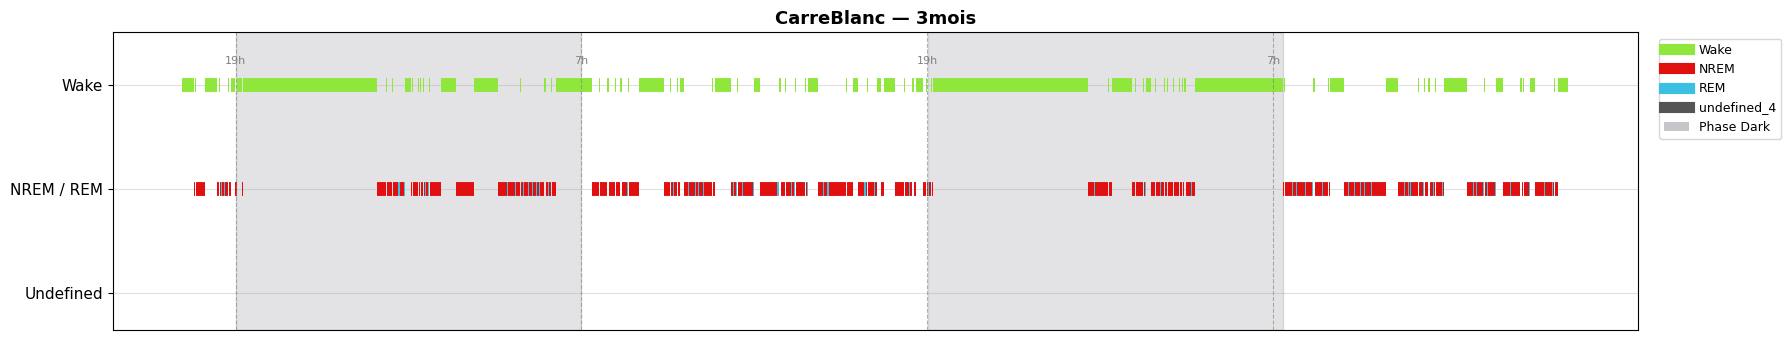

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreBlanc\3mois\Hypnogramme_CarreBlanc_3mois.png

  Souris : CarreBlanc  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   7178 epochs | duree totale : 48.28h
   Contenu recording_start.txt : [01/04/2026 16:09:54]
   Debut enregistrement : 2026-04-01 16:09:54  (format %d/%m/%Y %H:%M:%S)
   1201 episodes regroupe(s)


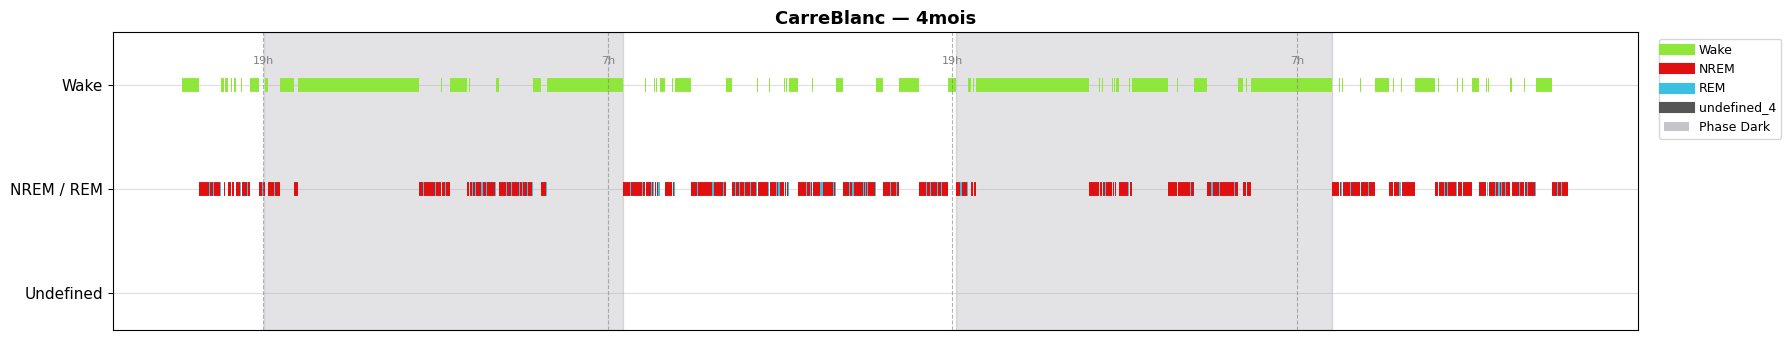

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreBlanc\4mois\Hypnogramme_CarreBlanc_4mois.png

  Souris : CarreJaune  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   34893 epochs | duree totale : 48.46h
   Contenu recording_start.txt : [09/03/2026 16:07:11]
   Debut enregistrement : 2026-03-09 16:07:11  (format %d/%m/%Y %H:%M:%S)
   4414 episodes regroupe(s)


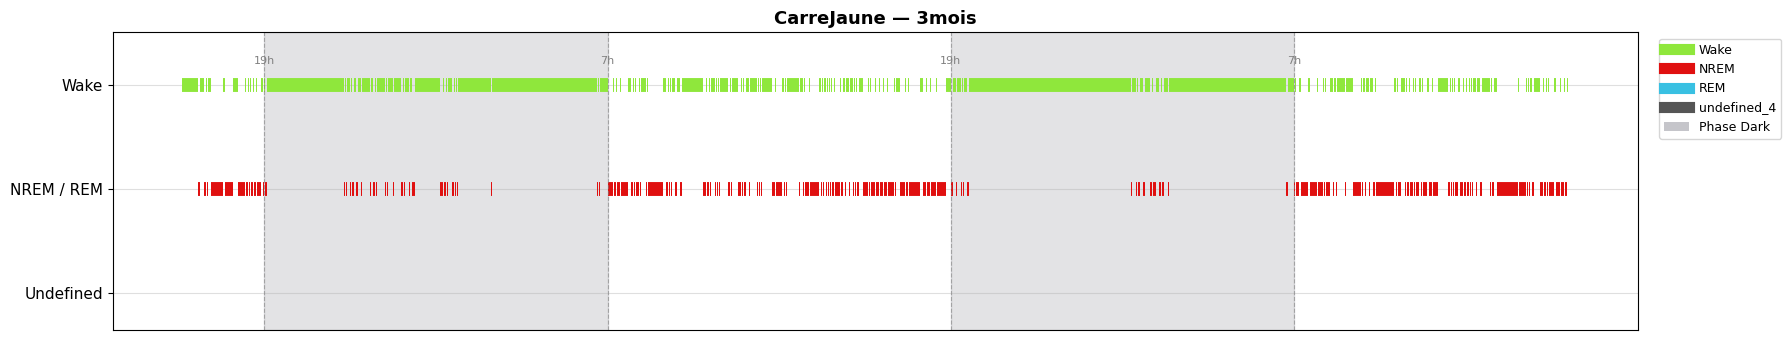

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreJaune\3mois\Hypnogramme_CarreJaune_3mois.png

  Souris : CarreMarron  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   14743 epochs | duree totale : 48.10h
   Contenu recording_start.txt : [23/02/2026 15:30:45]
   Debut enregistrement : 2026-02-23 15:30:45  (format %d/%m/%Y %H:%M:%S)
   979 episodes regroupe(s)


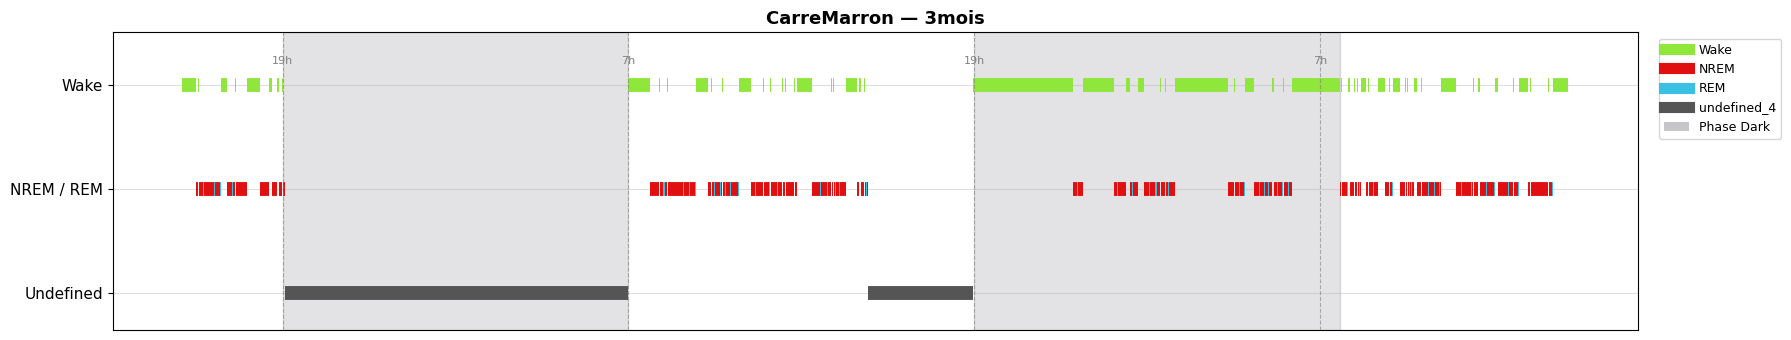

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreMarron\3mois\Hypnogramme_CarreMarron_3mois.png

  Souris : CarreMarron  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34995 epochs | duree totale : 48.60h
   Contenu recording_start.txt : [23/03/2026 15:33:38]
   Debut enregistrement : 2026-03-23 15:33:38  (format %d/%m/%Y %H:%M:%S)
   352 episodes regroupe(s)


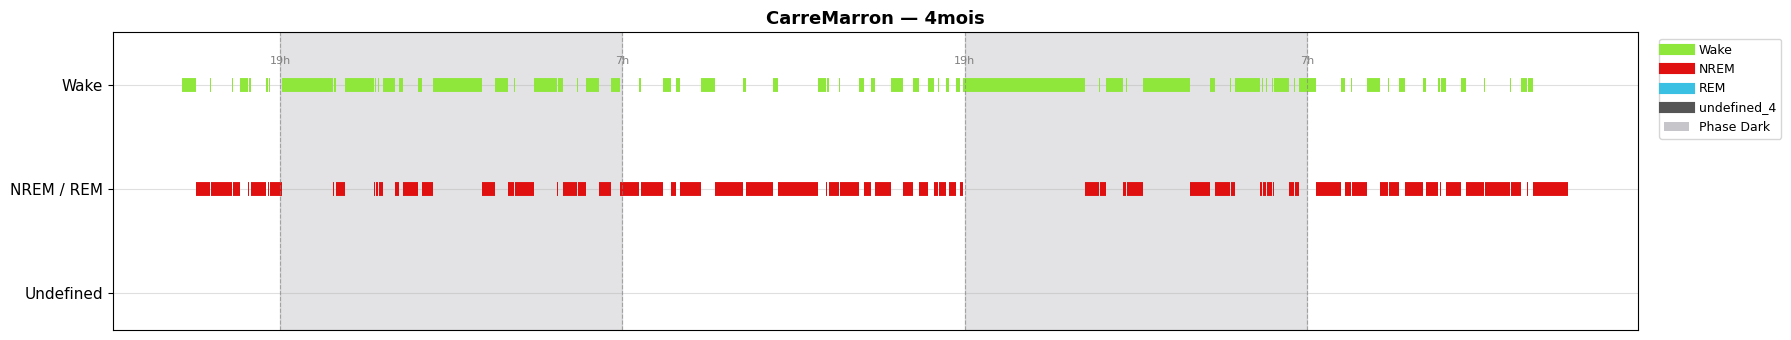

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreMarron\4mois\Hypnogramme_CarreMarron_4mois.png

  Souris : CarreNoir  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10055 epochs | duree totale : 48.11h
   Contenu recording_start.txt : [04/03/2026 17:08:21]
   Debut enregistrement : 2026-03-04 17:08:21  (format %d/%m/%Y %H:%M:%S)
   1759 episodes regroupe(s)


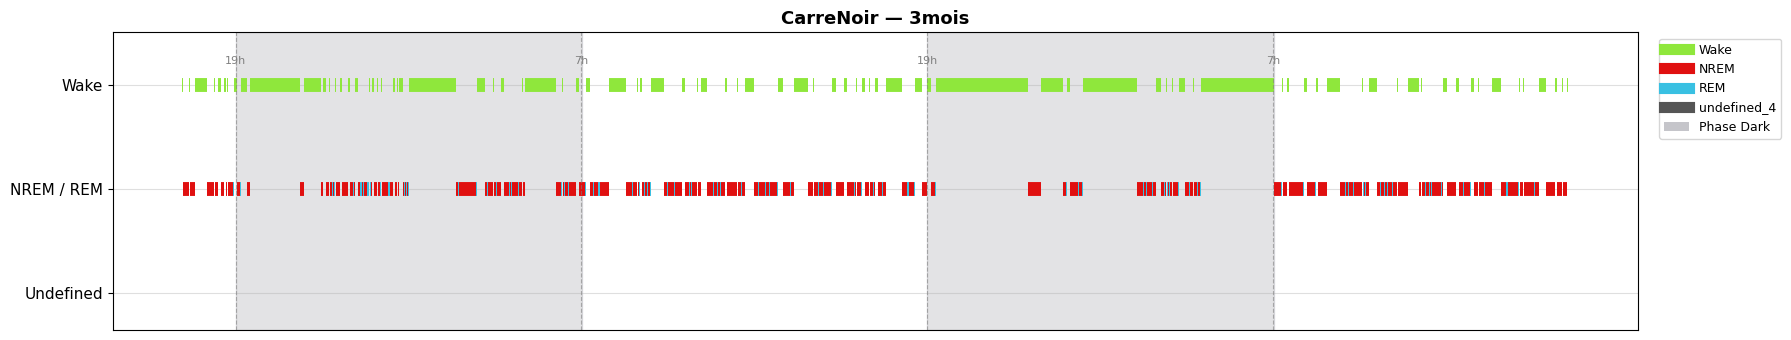

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreNoir\3mois\Hypnogramme_CarreNoir_3mois.png

  Souris : CarreNoir  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9405 epochs | duree totale : 48.28h
   Contenu recording_start.txt : [01/04/2026 16:09:54]
   Debut enregistrement : 2026-04-01 16:09:54  (format %d/%m/%Y %H:%M:%S)
   1432 episodes regroupe(s)


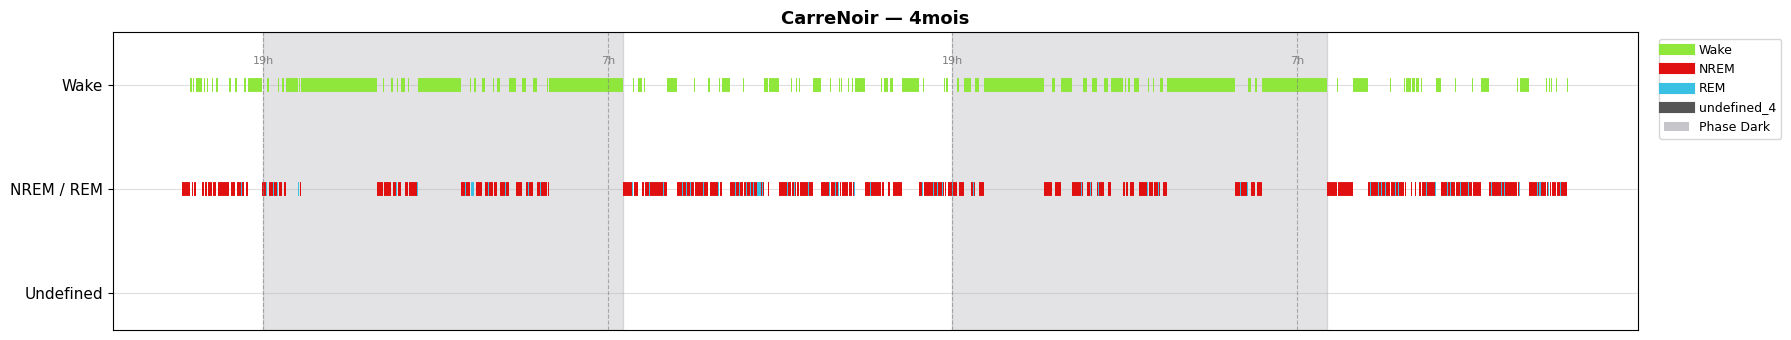

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreNoir\4mois\Hypnogramme_CarreNoir_4mois.png

  Souris : CarreOrange  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34636 epochs | duree totale : 48.11h
   Contenu recording_start.txt : [04/03/2026 17:08:21]
   Debut enregistrement : 2026-03-04 17:08:21  (format %d/%m/%Y %H:%M:%S)
   3345 episodes regroupe(s)


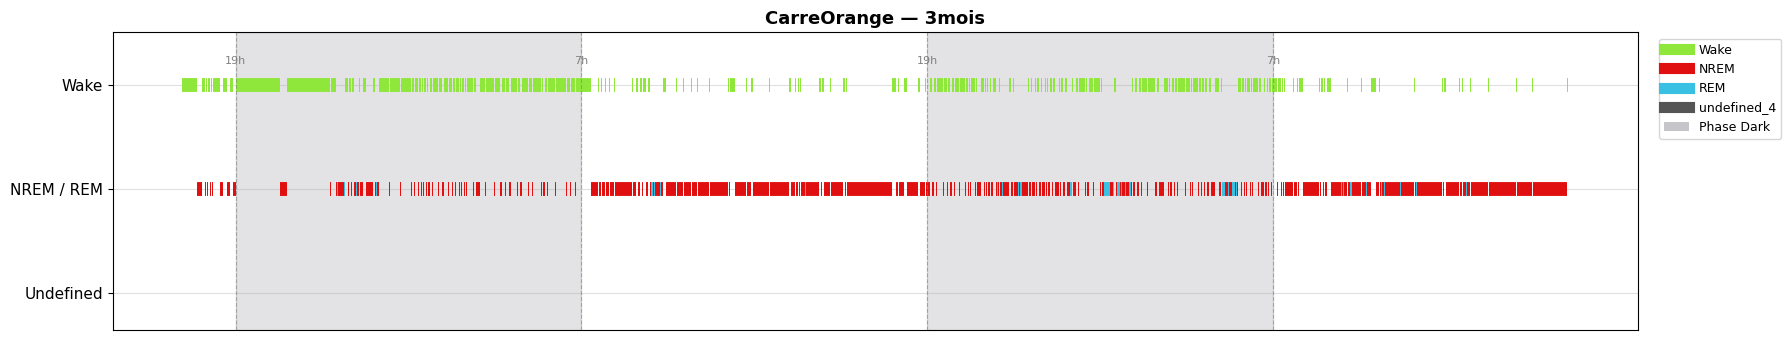

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreOrange\3mois\Hypnogramme_CarreOrange_3mois.png

  Souris : CarreOrange  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34764 epochs | duree totale : 48.28h
   Contenu recording_start.txt : [01/04/2026 19:09:54]
   Debut enregistrement : 2026-04-01 19:09:54  (format %d/%m/%Y %H:%M:%S)
   2409 episodes regroupe(s)


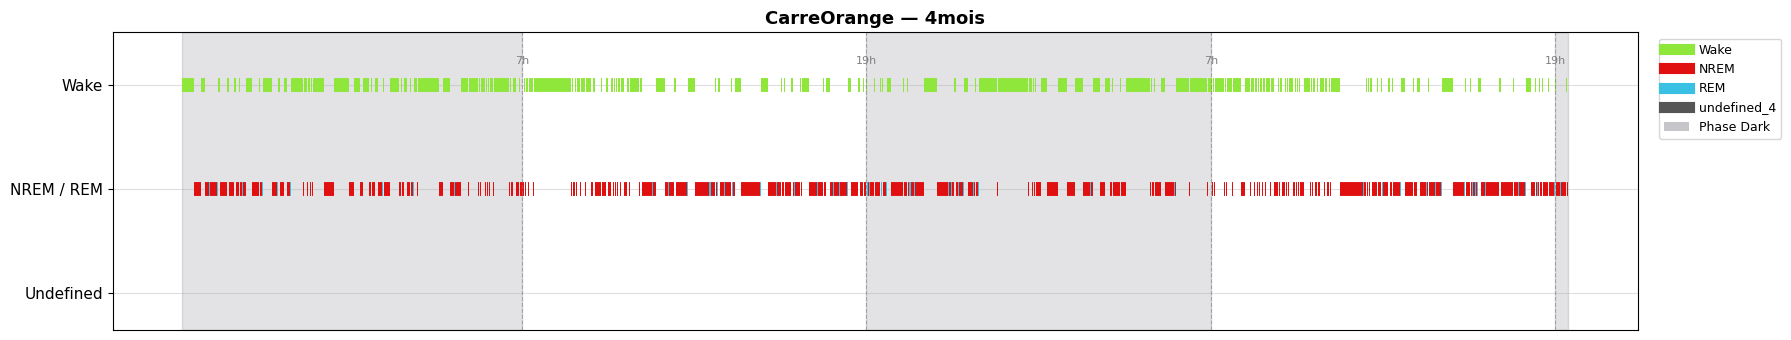

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreOrange\4mois\Hypnogramme_CarreOrange_4mois.png

  Souris : CarreRouge  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34633 epochs | duree totale : 48.10h
   Contenu recording_start.txt : [23/02/2026 15:30:45]
   Debut enregistrement : 2026-02-23 15:30:45  (format %d/%m/%Y %H:%M:%S)
   1765 episodes regroupe(s)


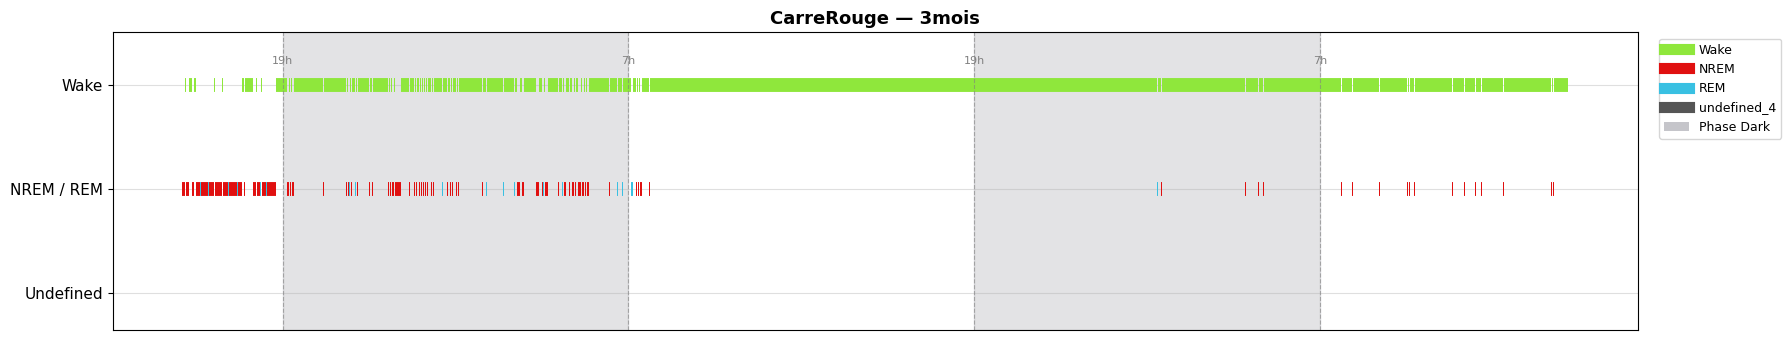

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreRouge\3mois\Hypnogramme_CarreRouge_3mois.png

  Souris : CarreRouge  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34995 epochs | duree totale : 48.60h
   Contenu recording_start.txt : [23/03/2026 15:33:38]
   Debut enregistrement : 2026-03-23 15:33:38  (format %d/%m/%Y %H:%M:%S)
   1292 episodes regroupe(s)


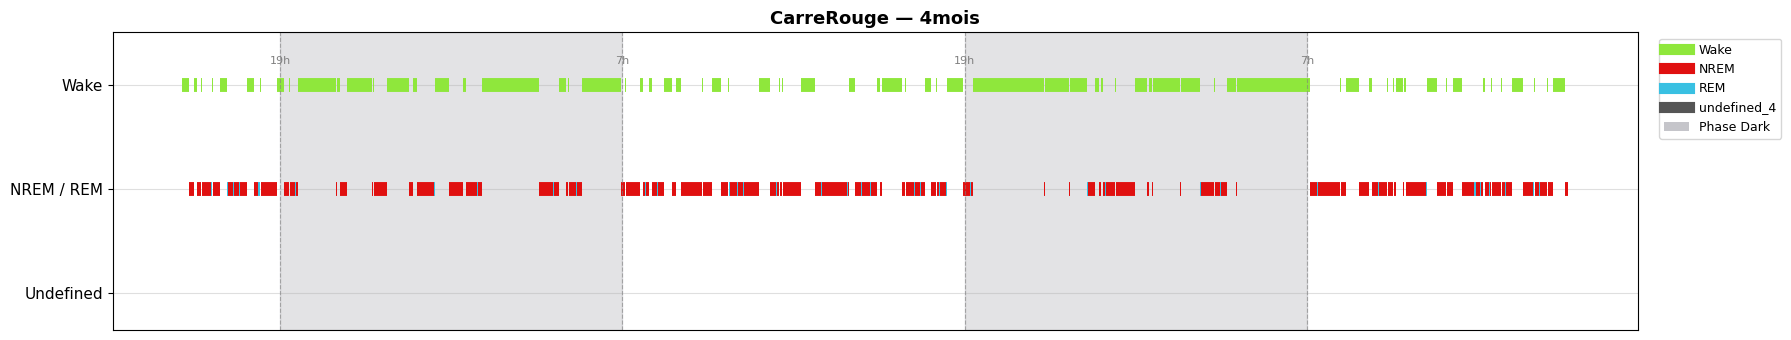

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreRouge\4mois\Hypnogramme_CarreRouge_4mois.png

  Souris : RondBleu  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   12861 epochs | duree totale : 17.86h
   Contenu recording_start.txt : [01/04/2025 16:52:14]
   Debut enregistrement : 2025-04-01 16:52:14  (format %d/%m/%Y %H:%M:%S)
   77 episodes regroupe(s)


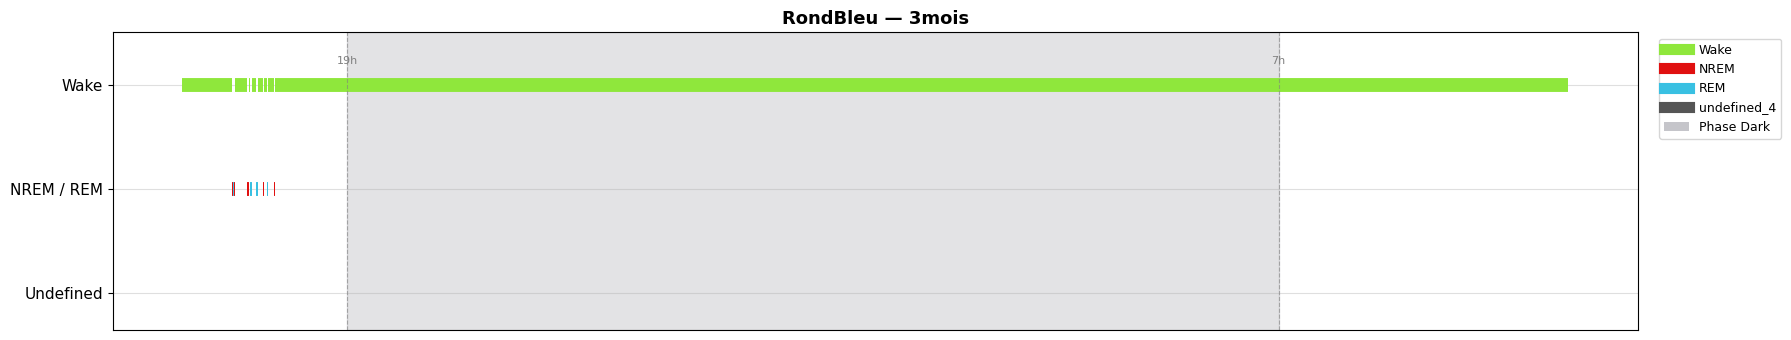

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondBleu\3mois\Hypnogramme_RondBleu_3mois.png

  Souris : RondMarron  |  Age : 3mois
   Separateur detecte : [;]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   47640 epochs | duree totale : 66.17h
   Contenu recording_start.txt : [07/04/2025 15:56:32]
   Debut enregistrement : 2025-04-07 15:56:32  (format %d/%m/%Y %H:%M:%S)
   6104 episodes regroupe(s)


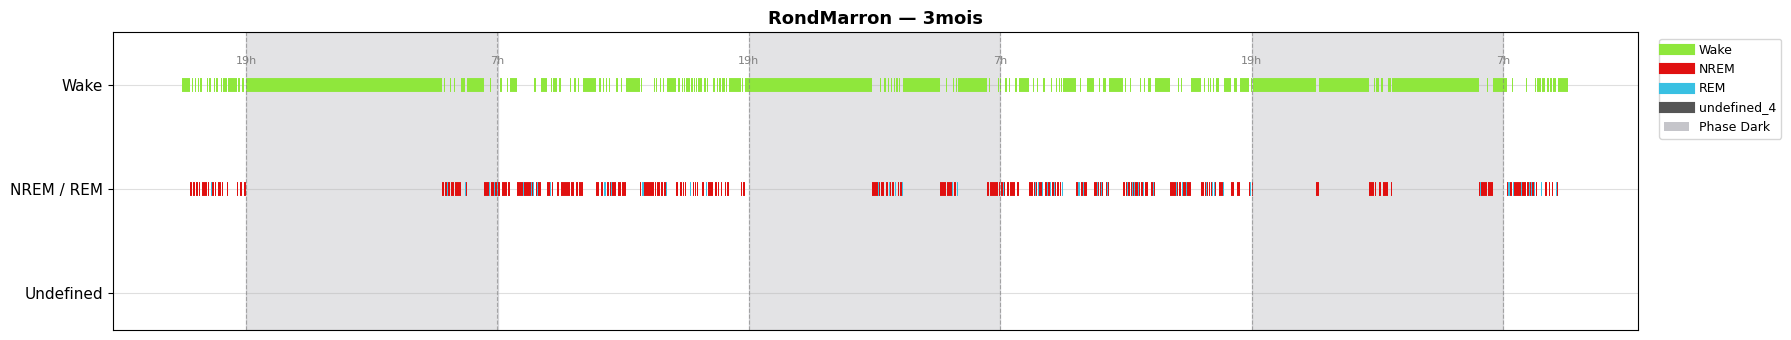

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondMarron\3mois\Hypnogramme_RondMarron_3mois.png

  Souris : RondMarron  |  Age : 6mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34636 epochs | duree totale : 48.11h
   Contenu recording_start.txt : [24/06/2025 16:08:24]
   Debut enregistrement : 2025-06-24 16:08:24  (format %d/%m/%Y %H:%M:%S)
   510 episodes regroupe(s)


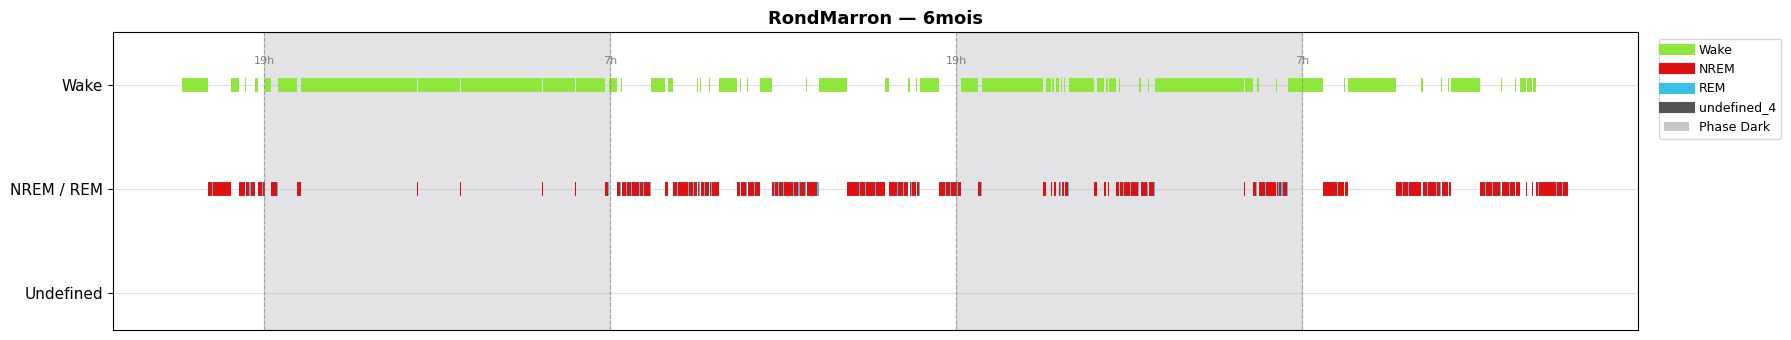

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondMarron\6mois\Hypnogramme_RondMarron_6mois.png

  Souris : RondOrange  |  Age : 5mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   4855 epochs | duree totale : 6.74h
   Contenu recording_start.txt : [10/06/2025 16:14:53]
   Debut enregistrement : 2025-06-10 16:14:53  (format %d/%m/%Y %H:%M:%S)
   253 episodes regroupe(s)


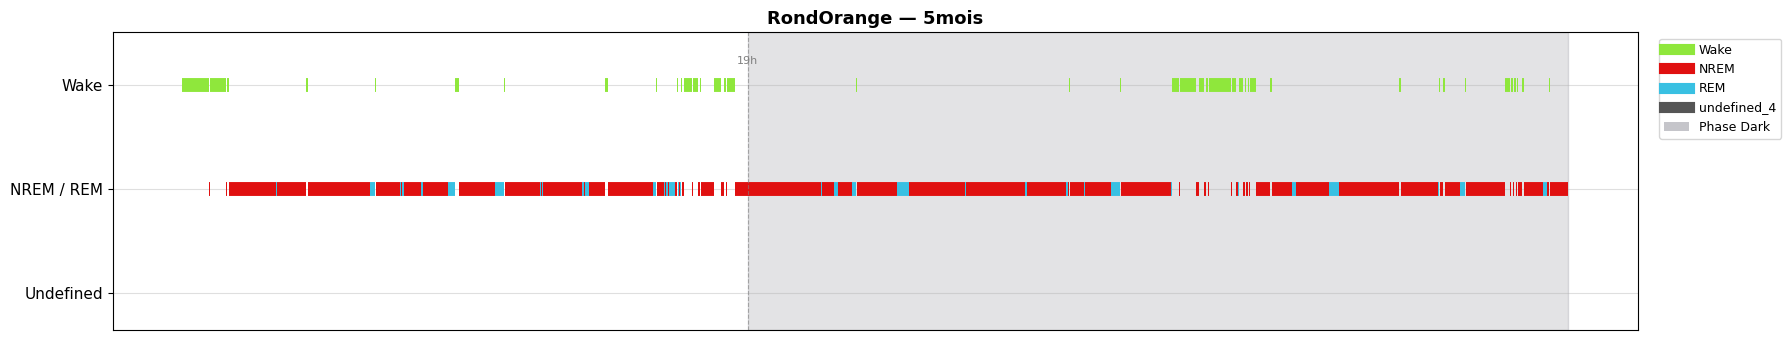

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondOrange\5mois\Hypnogramme_RondOrange_5mois.png

  Souris : TraitRouge  |  Age : 10mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   35379 epochs | duree totale : 49.14h
   Contenu recording_start.txt : [25/08/2025 16:44:29]
   Debut enregistrement : 2025-08-25 16:44:29  (format %d/%m/%Y %H:%M:%S)
   1303 episodes regroupe(s)


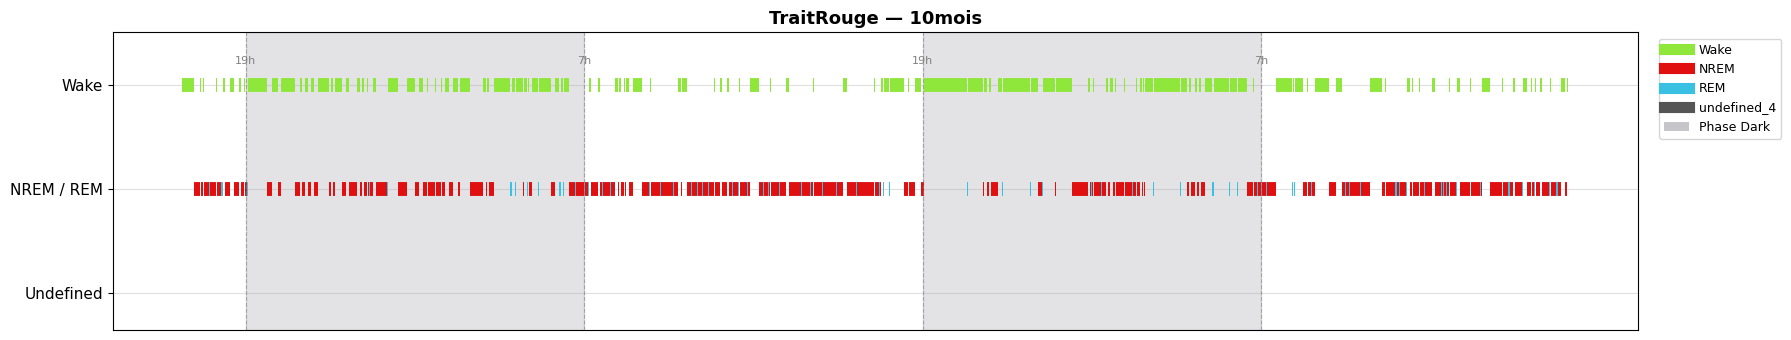

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\10mois\Hypnogramme_TraitRouge_10mois.png

  Souris : TraitRouge  |  Age : 11mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   35379 epochs | duree totale : 49.14h
   Contenu recording_start.txt : [30/09/2025 08:55:04]
   Debut enregistrement : 2025-09-30 08:55:04  (format %d/%m/%Y %H:%M:%S)
   1090 episodes regroupe(s)


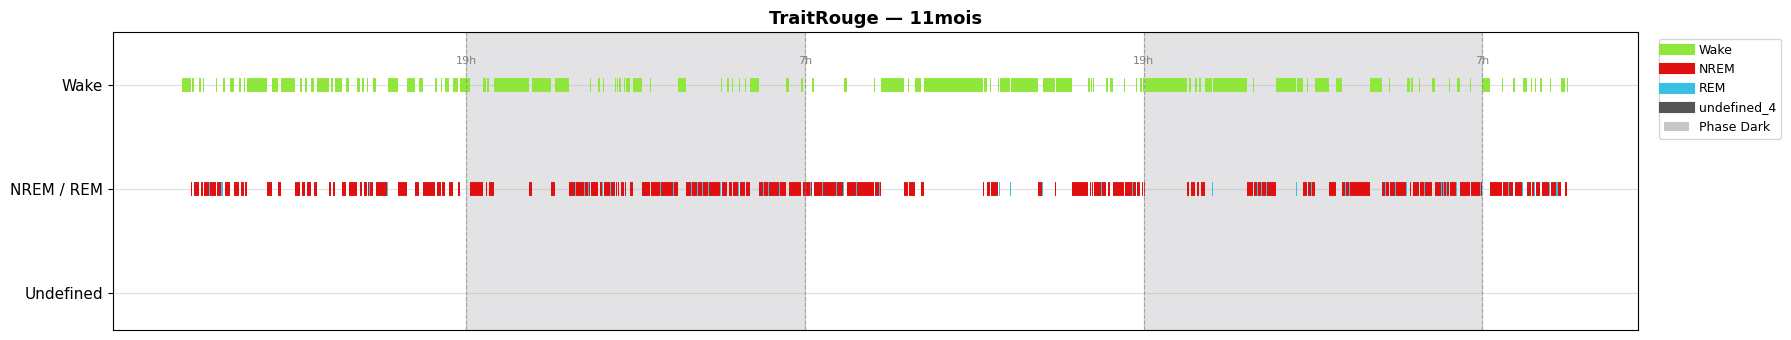

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\11mois\Hypnogramme_TraitRouge_11mois.png

  Souris : TraitRouge  |  Age : 12mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34650 epochs | duree totale : 48.12h
   Contenu recording_start.txt : [27/10/2025 15:59:41]
   Debut enregistrement : 2025-10-27 15:59:41  (format %d/%m/%Y %H:%M:%S)
   969 episodes regroupe(s)


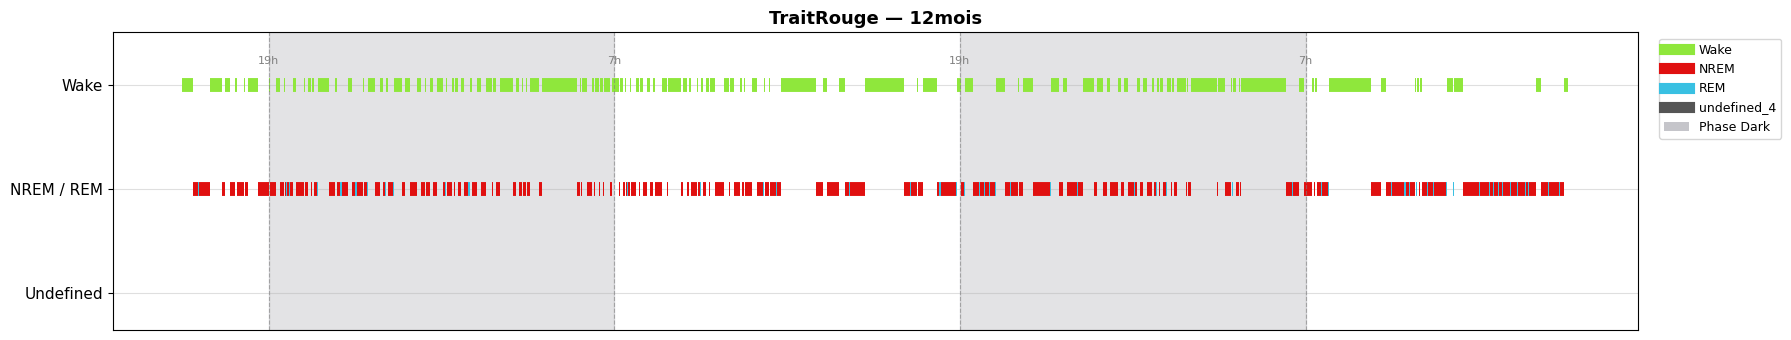

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\12mois\Hypnogramme_TraitRouge_12mois.png

  Souris : TraitRouge  |  Age : 5mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   45593 epochs | duree totale : 63.32h
   Contenu recording_start.txt : [28/03/2025 17:29:35]
   Debut enregistrement : 2025-03-28 17:29:35  (format %d/%m/%Y %H:%M:%S)
   1863 episodes regroupe(s)


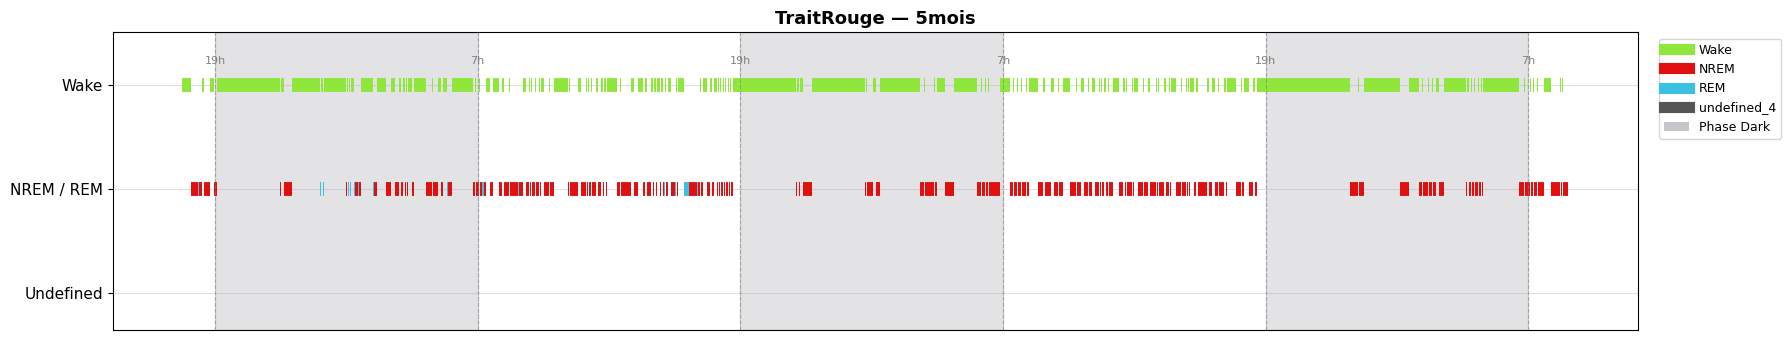

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\5mois\Hypnogramme_TraitRouge_5mois.png

  Souris : TraitRouge  |  Age : 7mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34716 epochs | duree totale : 48.22h
   Contenu recording_start.txt : [26/05/2025 17:01:34]
   Debut enregistrement : 2025-05-26 17:01:34  (format %d/%m/%Y %H:%M:%S)
   1238 episodes regroupe(s)


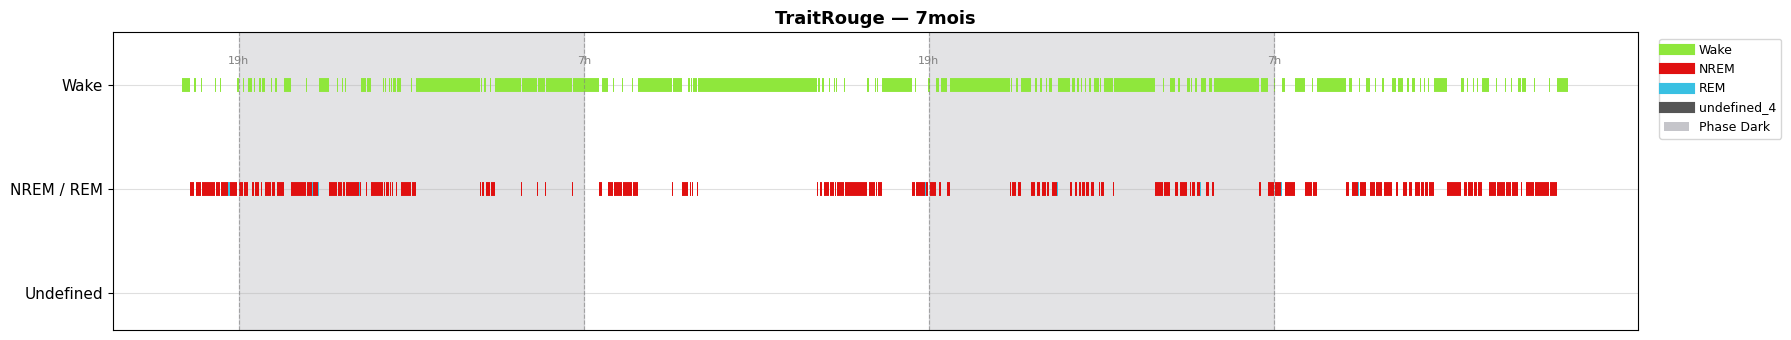

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\7mois\Hypnogramme_TraitRouge_7mois.png

  Souris : TraitRouge  |  Age : 9mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   39116 epochs | duree totale : 54.33h
   Contenu recording_start.txt : [26/07/2025 10:26:14]
   Debut enregistrement : 2025-07-26 10:26:14  (format %d/%m/%Y %H:%M:%S)
   805 episodes regroupe(s)


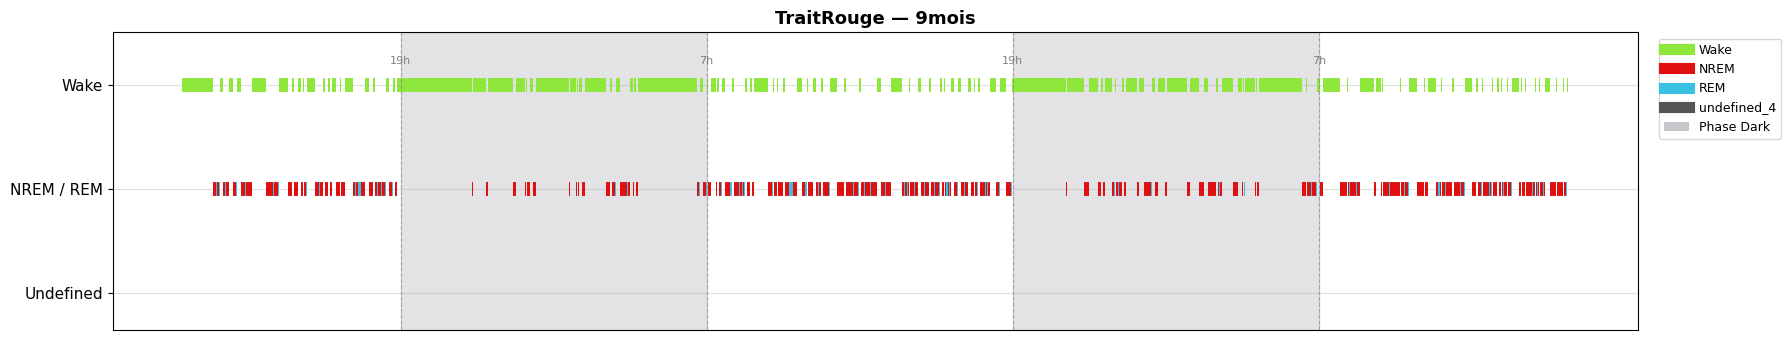

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\9mois\Hypnogramme_TraitRouge_9mois.png

  Souris : TraitViolet  |  Age : 10mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   35379 epochs | duree totale : 49.14h
   Contenu recording_start.txt : [25/08/2025 16:44:29]
   Debut enregistrement : 2025-08-25 16:44:29  (format %d/%m/%Y %H:%M:%S)
   1505 episodes regroupe(s)


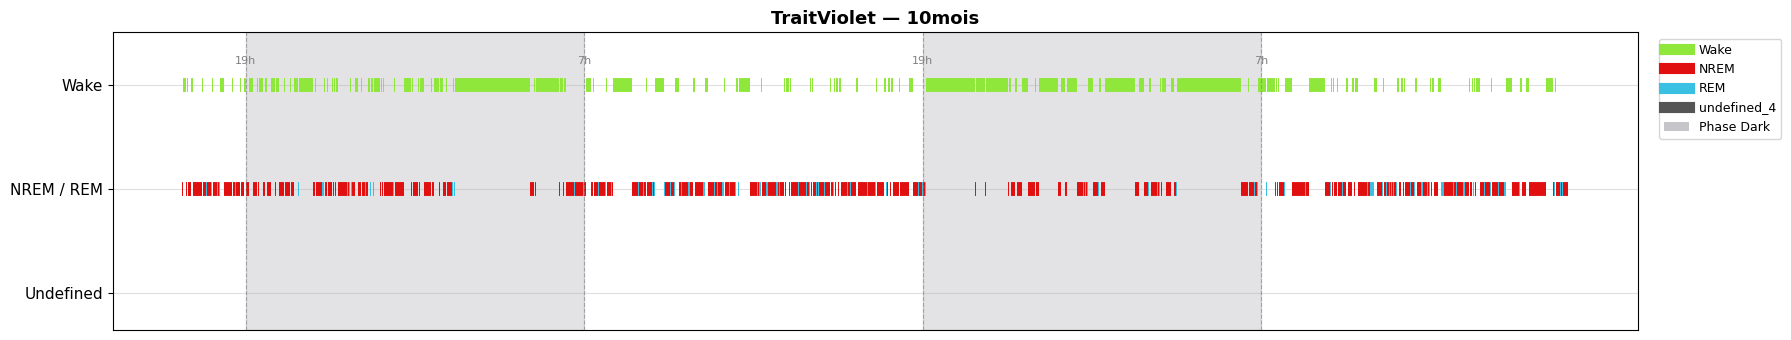

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitViolet\10mois\Hypnogramme_TraitViolet_10mois.png

  Souris : TraitViolet  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   45706 epochs | duree totale : 63.38h
   Contenu recording_start.txt : [28/02/2025 17:57:01]
   Debut enregistrement : 2025-02-28 17:57:01  (format %d/%m/%Y %H:%M:%S)
   2321 episodes regroupe(s)


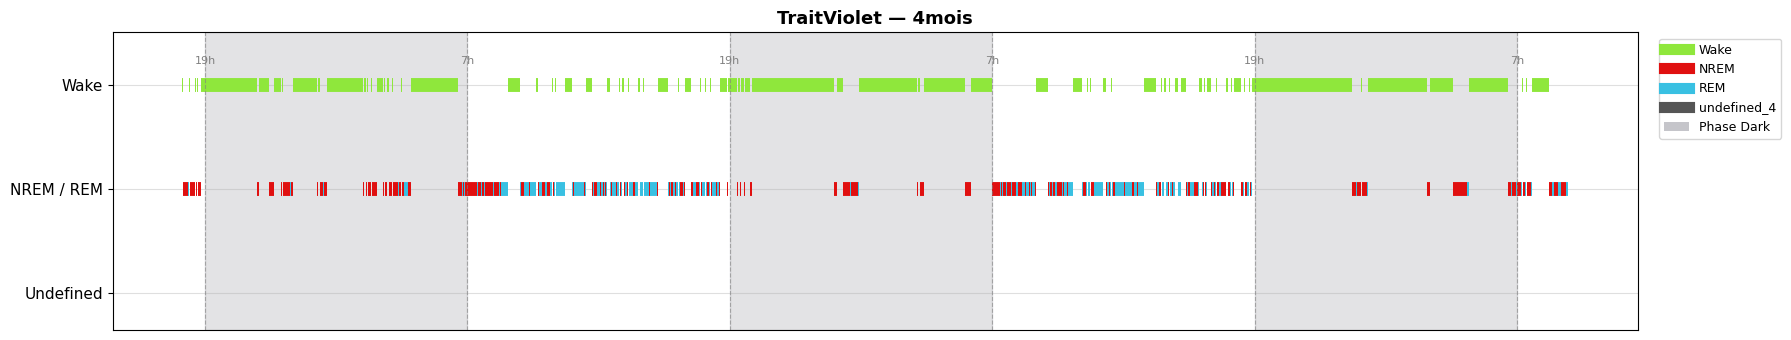

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitViolet\4mois\Hypnogramme_TraitViolet_4mois.png

  Souris : TraitViolet  |  Age : 5mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   45593 epochs | duree totale : 63.32h
   Contenu recording_start.txt : [28/03/2025 17:29:35]
   Debut enregistrement : 2025-03-28 17:29:35  (format %d/%m/%Y %H:%M:%S)
   532 episodes regroupe(s)


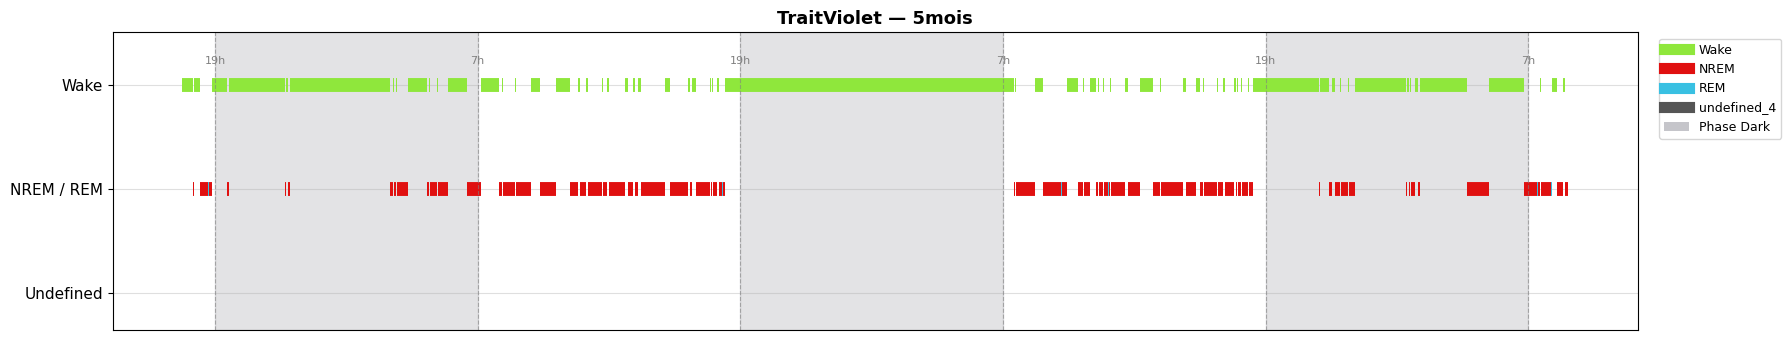

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitViolet\5mois\Hypnogramme_TraitViolet_5mois.png

  Souris : TraitViolet  |  Age : 7mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34716 epochs | duree totale : 48.22h
   Contenu recording_start.txt : [26/05/2025 17:01:34]
   Debut enregistrement : 2025-05-26 17:01:34  (format %d/%m/%Y %H:%M:%S)
   3827 episodes regroupe(s)


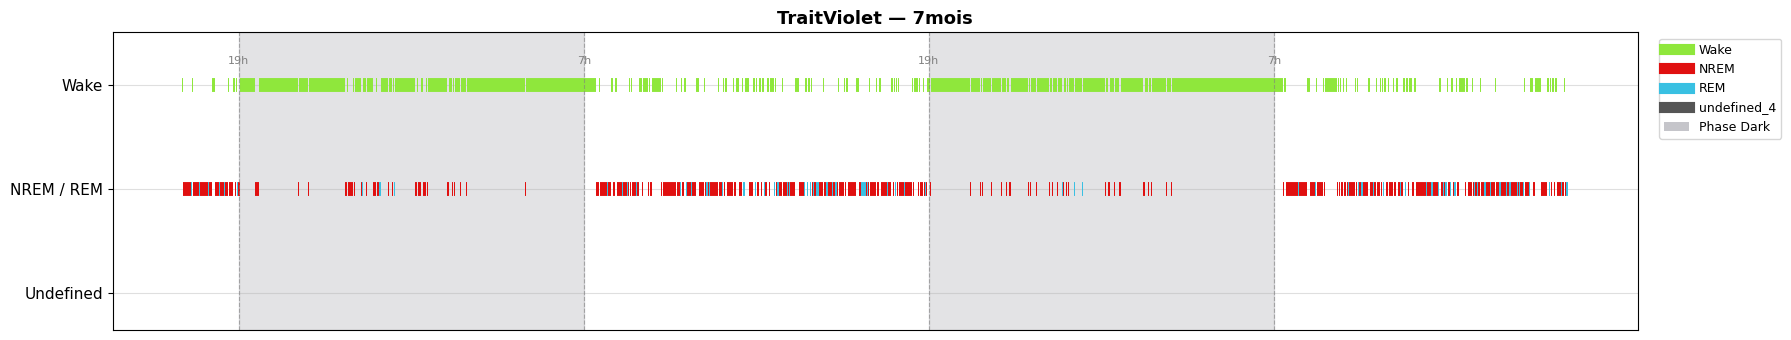

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitViolet\7mois\Hypnogramme_TraitViolet_7mois.png

  Souris : TraitViolet  |  Age : 9mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   39116 epochs | duree totale : 54.33h
   Contenu recording_start.txt : [26/07/2025 10:26:14]
   Debut enregistrement : 2025-07-26 10:26:14  (format %d/%m/%Y %H:%M:%S)
   4574 episodes regroupe(s)


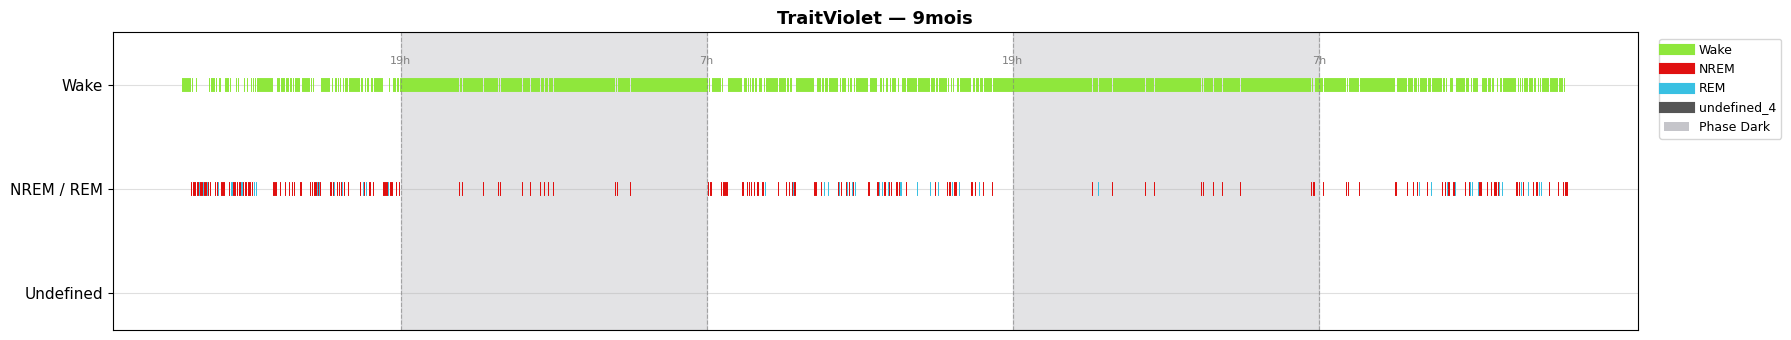

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitViolet\9mois\Hypnogramme_TraitViolet_9mois.png

  Souris : TriangleBlanc  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   5222 epochs | duree totale : 48.29h
   Contenu recording_start.txt : [19/08/2025 16:25:28]
   Debut enregistrement : 2025-08-19 16:25:28  (format %d/%m/%Y %H:%M:%S)
   1168 episodes regroupe(s)


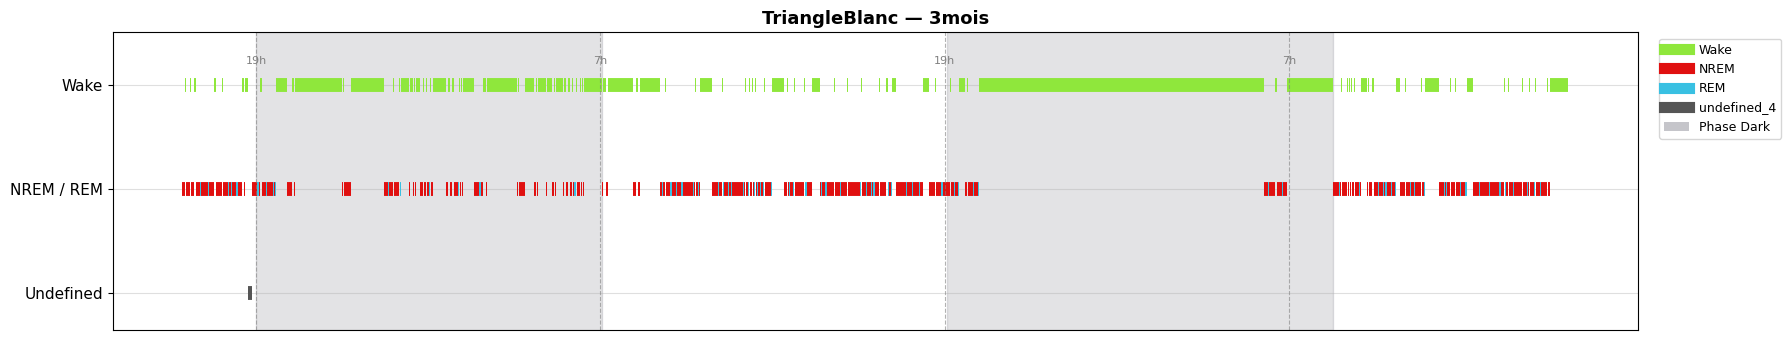

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBlanc\3mois\Hypnogramme_TriangleBlanc_3mois.png

  Souris : TriangleBlanc  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9352 epochs | duree totale : 48.42h
   Contenu recording_start.txt : [24/09/2025 16:33:51]
   Debut enregistrement : 2025-09-24 16:33:51  (format %d/%m/%Y %H:%M:%S)
   1577 episodes regroupe(s)


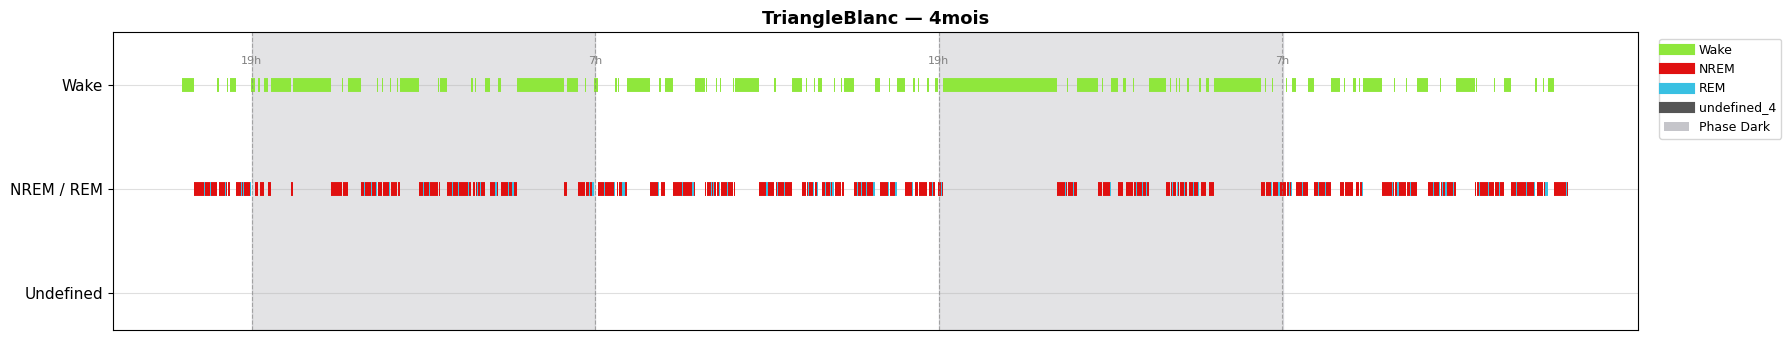

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBlanc\4mois\Hypnogramme_TriangleBlanc_4mois.png

  Souris : TriangleBlanc  |  Age : 5mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   7873 epochs | duree totale : 48.54h
   Contenu recording_start.txt : [22/10/2025 16:20:15]
   Debut enregistrement : 2025-10-22 16:20:15  (format %d/%m/%Y %H:%M:%S)
   1152 episodes regroupe(s)


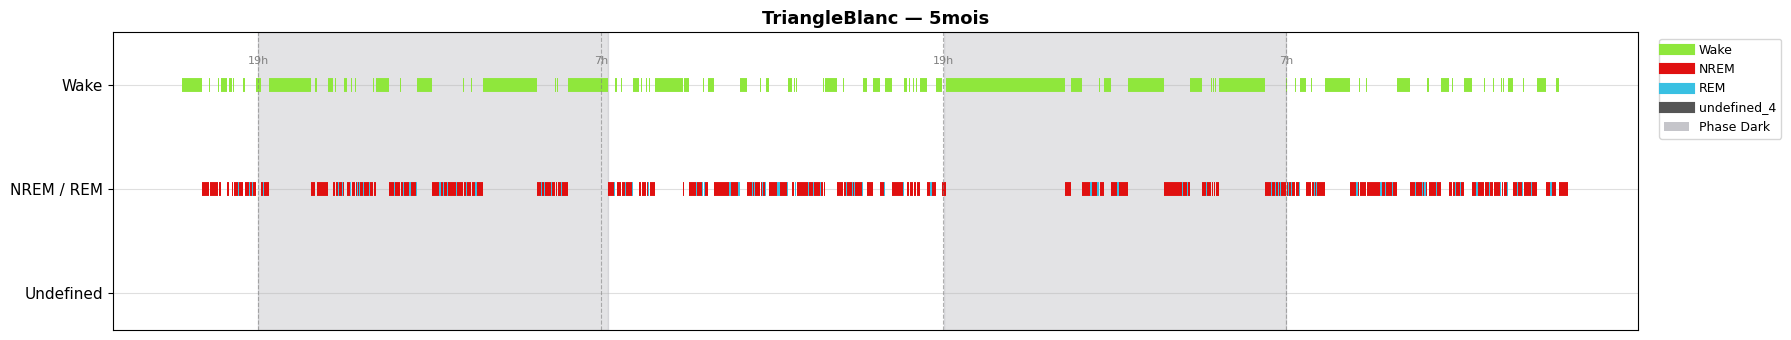

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBlanc\5mois\Hypnogramme_TriangleBlanc_5mois.png

  Souris : TriangleBlanc  |  Age : 6mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   35377 epochs | duree totale : 49.11h
   Contenu recording_start.txt : [24/11/2025 16:35:44]
   Debut enregistrement : 2025-11-24 16:35:44  (format %d/%m/%Y %H:%M:%S)
   1047 episodes regroupe(s)


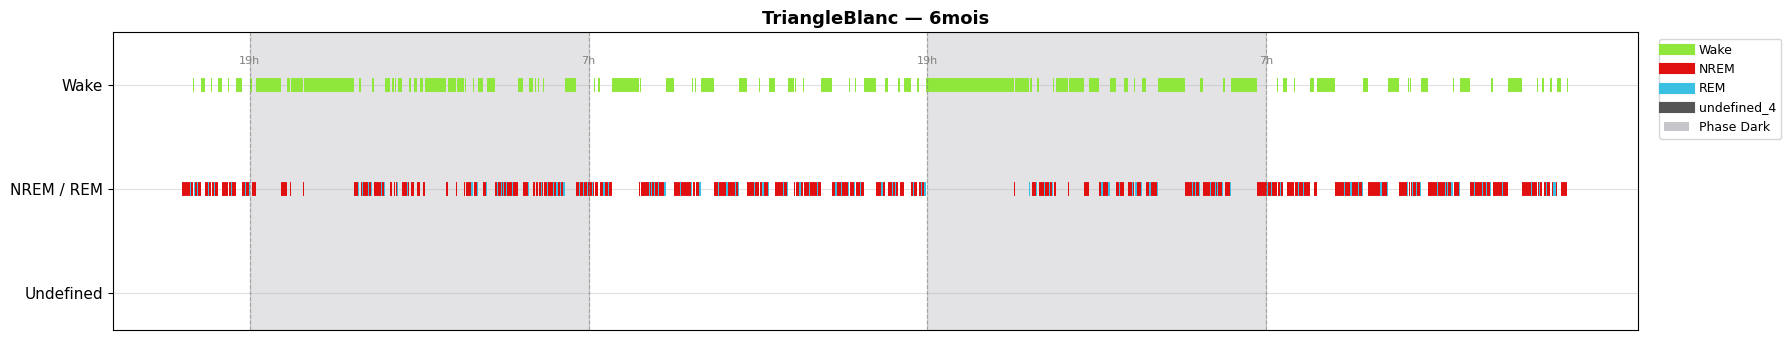

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBlanc\6mois\Hypnogramme_TriangleBlanc_6mois.png

  Souris : TriangleBlanc  |  Age : 7mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8933 epochs | duree totale : 49.26h
   Contenu recording_start.txt : [17/12/2025 16:47:38]
   Debut enregistrement : 2025-12-17 16:47:38  (format %d/%m/%Y %H:%M:%S)
   1617 episodes regroupe(s)


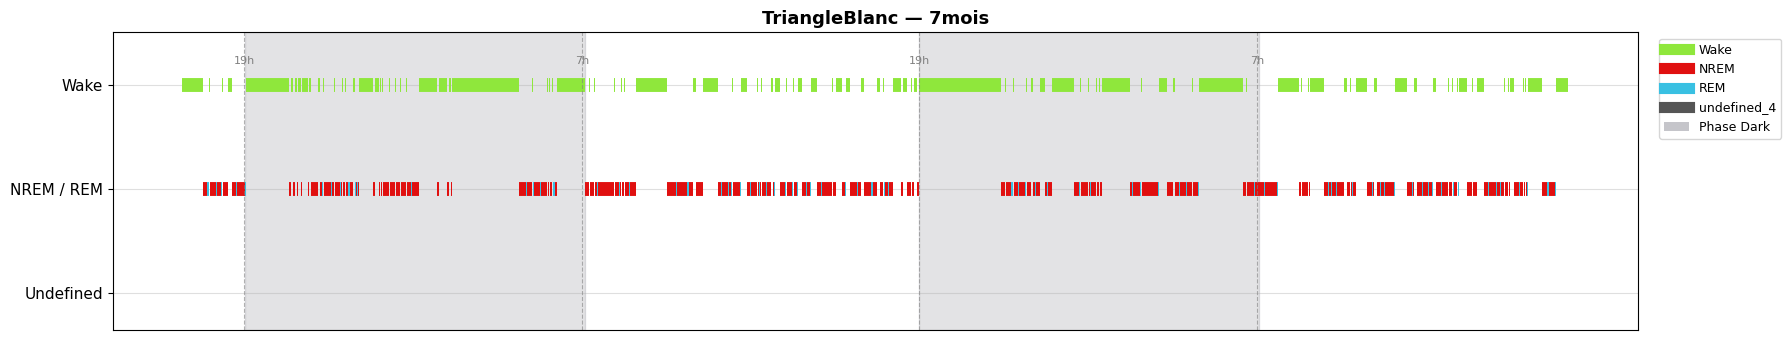

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBlanc\7mois\Hypnogramme_TriangleBlanc_7mois.png

  Souris : TriangleBleu  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   34358 epochs | duree totale : 47.66h
   Contenu recording_start.txt : [09/09/2025 17:25:54]
   Debut enregistrement : 2025-09-09 17:25:54  (format %d/%m/%Y %H:%M:%S)
   1097 episodes regroupe(s)


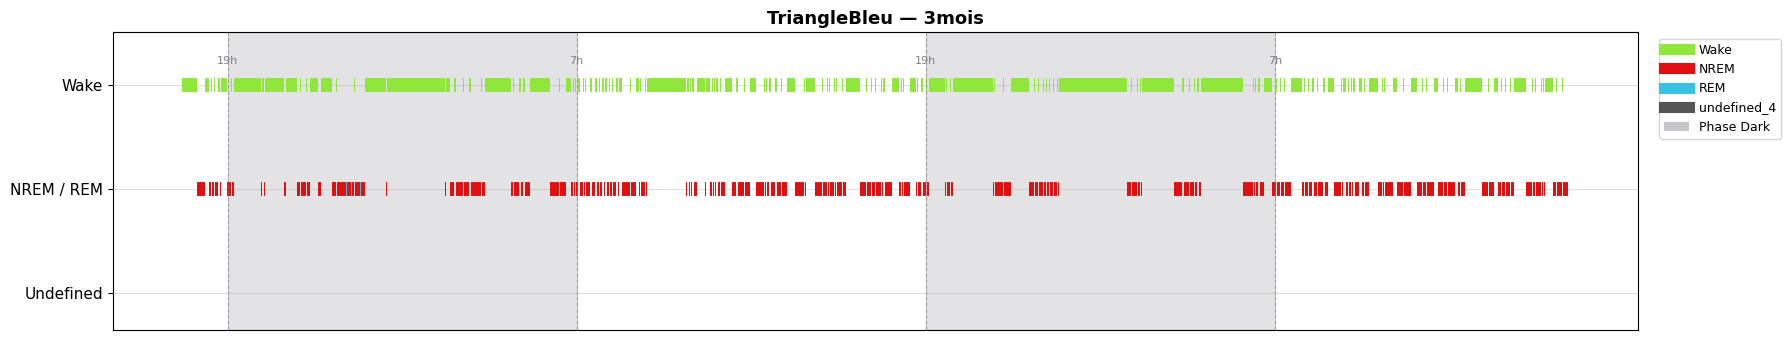

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBleu\3mois\Hypnogramme_TriangleBleu_3mois.png

  Souris : TriangleBleu  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46406 epochs | duree totale : 64.45h
   Contenu recording_start.txt : [14/10/2025 16:26:19]
   Debut enregistrement : 2025-10-14 16:26:19  (format %d/%m/%Y %H:%M:%S)
   1856 episodes regroupe(s)


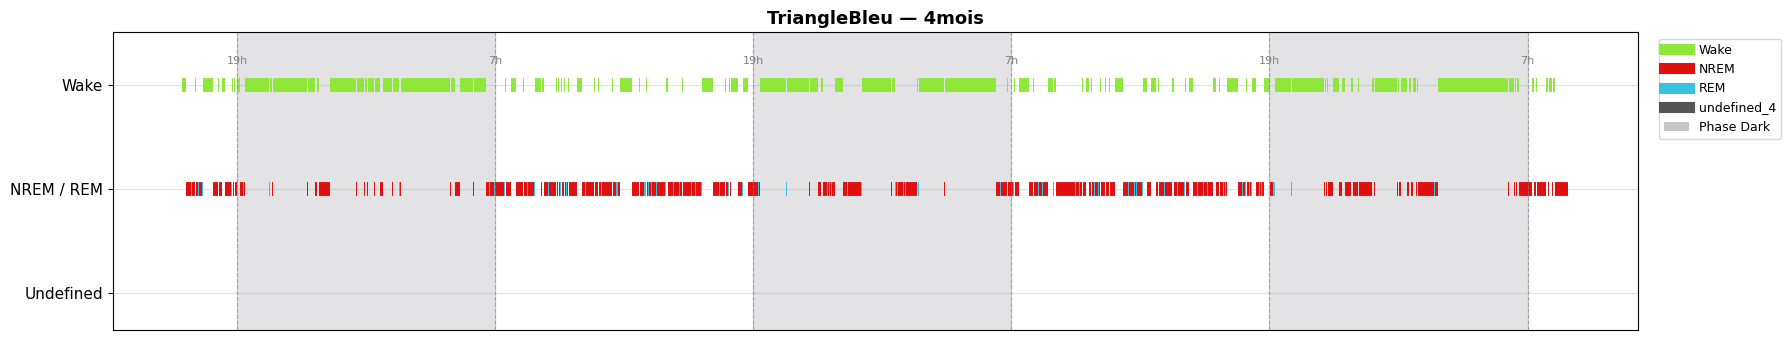

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBleu\4mois\Hypnogramme_TriangleBleu_4mois.png

  Souris : TriangleBleu  |  Age : 5mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34895 epochs | duree totale : 48.47h
   Contenu recording_start.txt : [12/11/2025 17:35:16]
   Debut enregistrement : 2025-11-12 17:35:16  (format %d/%m/%Y %H:%M:%S)
   1 episodes regroupe(s)


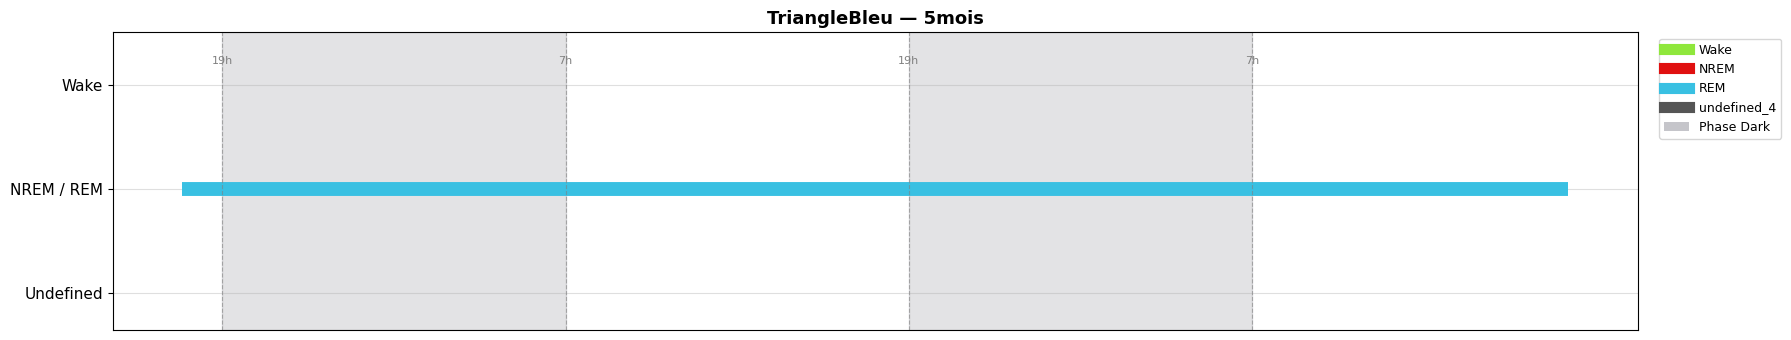

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBleu\5mois\Hypnogramme_TriangleBleu_5mois.png

  Souris : TriangleBleu  |  Age : 6mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10446 epochs | duree totale : 48.76h
   Contenu recording_start.txt : [08/12/2025 17:02:15]
   Debut enregistrement : 2025-12-08 17:02:15  (format %d/%m/%Y %H:%M:%S)
   2565 episodes regroupe(s)


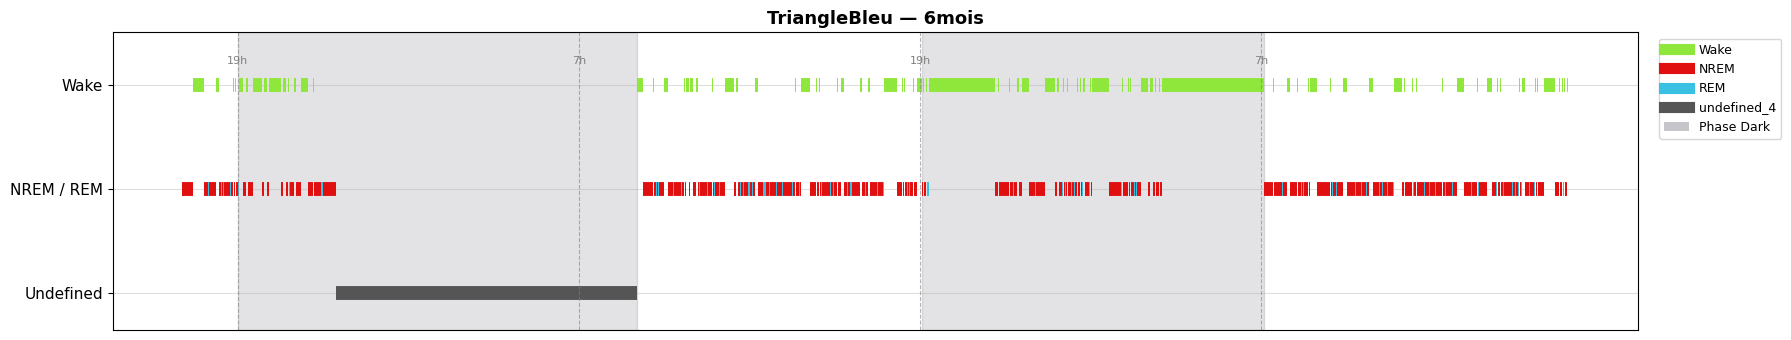

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBleu\6mois\Hypnogramme_TriangleBleu_6mois.png

  Souris : TriangleBleu  |  Age : 7mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9437 epochs | duree totale : 47.96h
   Contenu recording_start.txt : [14/01/2026 17:23:19]
   Debut enregistrement : 2026-01-14 17:23:19  (format %d/%m/%Y %H:%M:%S)
   2116 episodes regroupe(s)


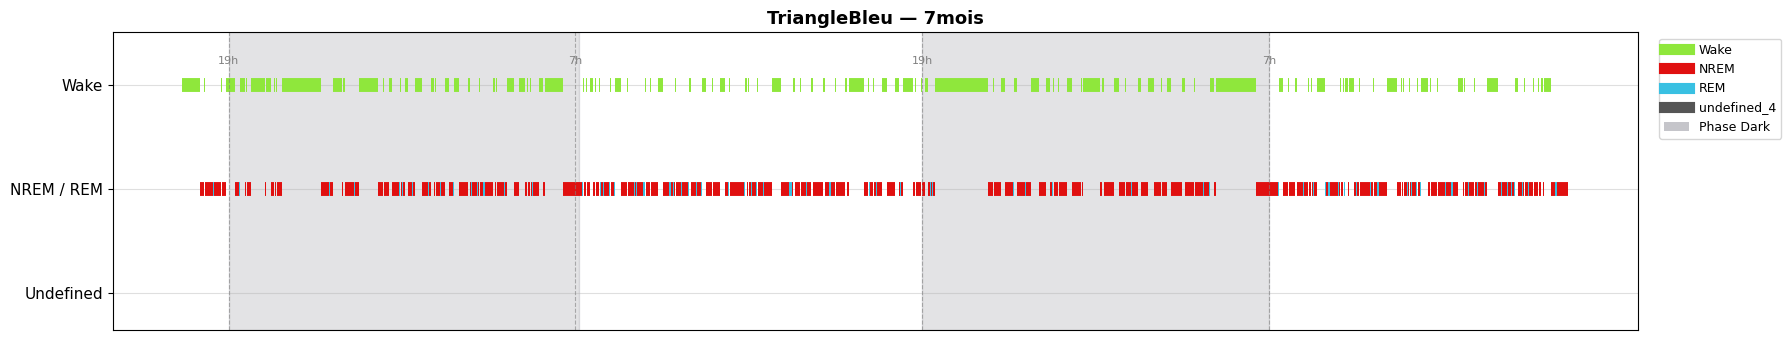

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBleu\7mois\Hypnogramme_TriangleBleu_7mois.png

  Souris : TriangleJaune  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34767 epochs | duree totale : 48.29h
   Contenu recording_start.txt : [19/08/2026 16:25:28]
   Debut enregistrement : 2026-08-19 16:25:28  (format %d/%m/%Y %H:%M:%S)
   1 episodes regroupe(s)


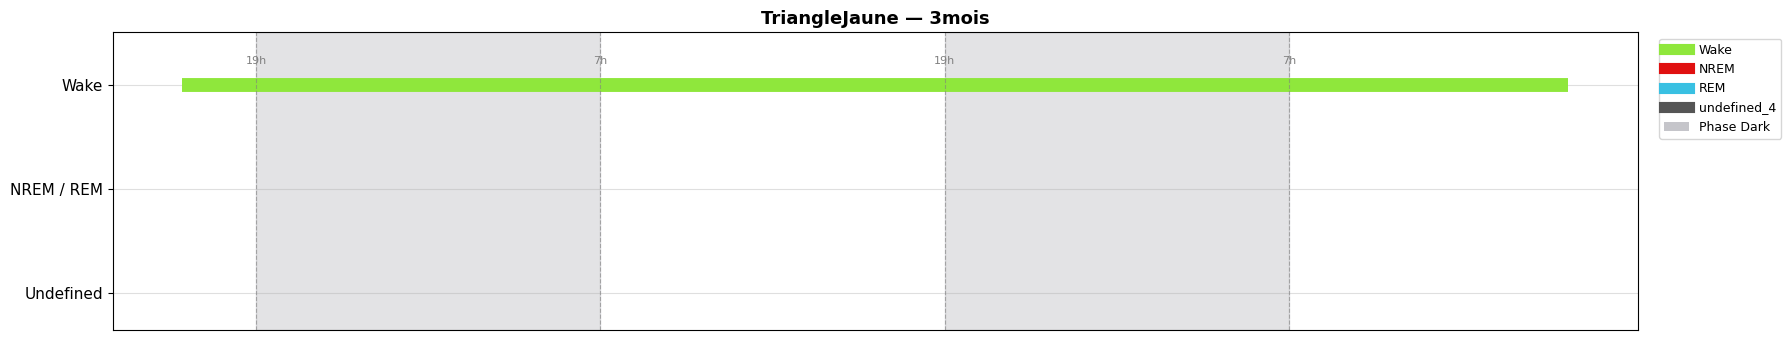

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleJaune\3mois\Hypnogramme_TriangleJaune_3mois.png

  Souris : TriangleJaune  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46702 epochs | duree totale : 64.86h
   Contenu recording_start.txt : [24/09/2025 16:33:51]
   Debut enregistrement : 2025-09-24 16:33:51  (format %d/%m/%Y %H:%M:%S)
   1554 episodes regroupe(s)


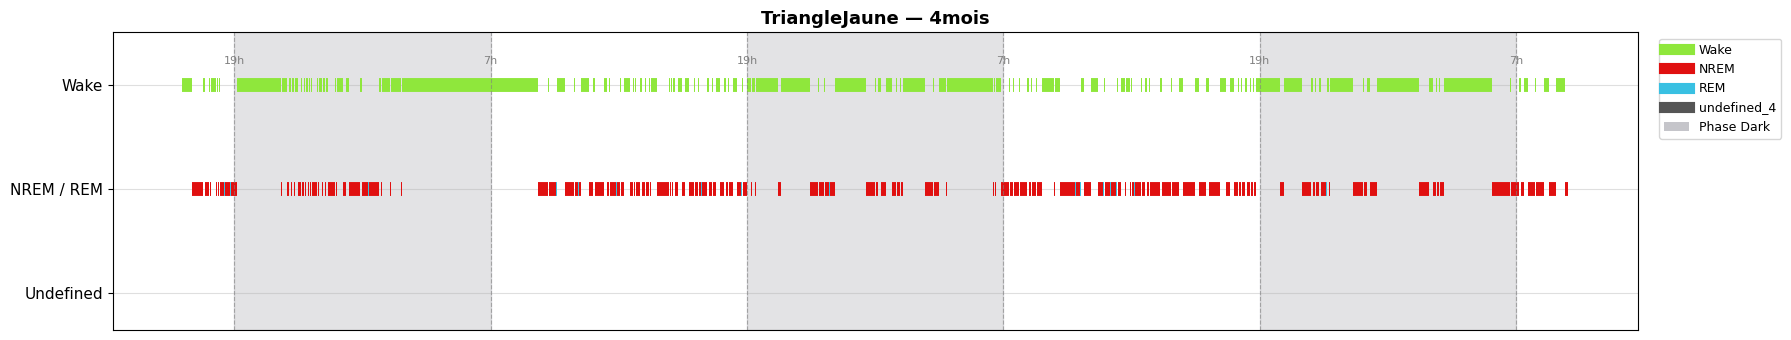

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleJaune\4mois\Hypnogramme_TriangleJaune_4mois.png

  Souris : TriangleJaune  |  Age : 5mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34952 epochs | duree totale : 48.54h
   Contenu recording_start.txt : [22/10/2025 16:20:15]
   Debut enregistrement : 2025-10-22 16:20:15  (format %d/%m/%Y %H:%M:%S)
   1075 episodes regroupe(s)


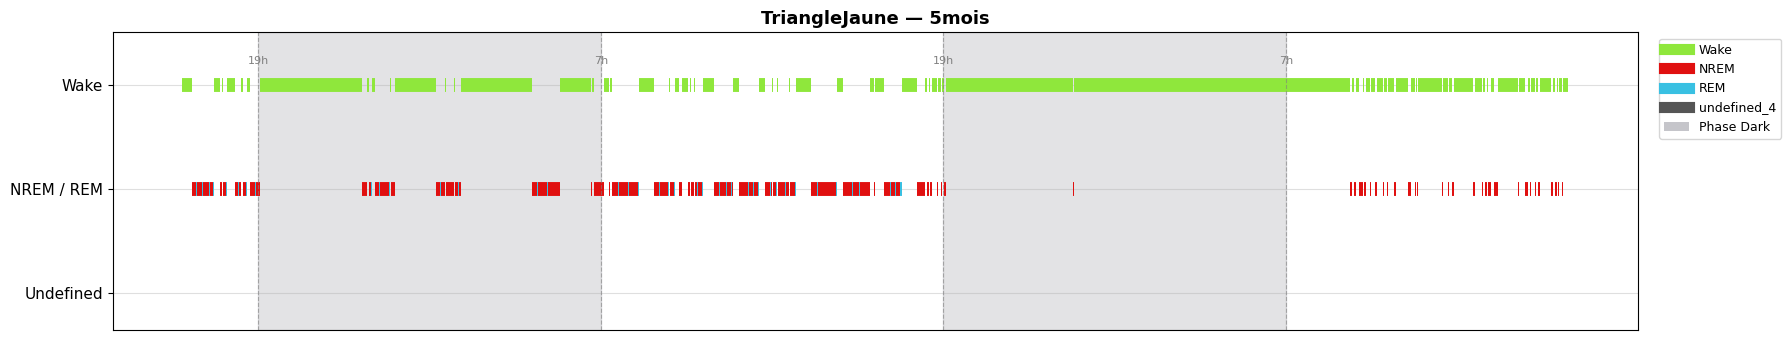

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleJaune\5mois\Hypnogramme_TriangleJaune_5mois.png

  Souris : TriangleJaune  |  Age : 6mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   35362 epochs | duree totale : 49.11h
   Contenu recording_start.txt : [24/11/2025 16:35:44]
   Debut enregistrement : 2025-11-24 16:35:44  (format %d/%m/%Y %H:%M:%S)
   2325 episodes regroupe(s)


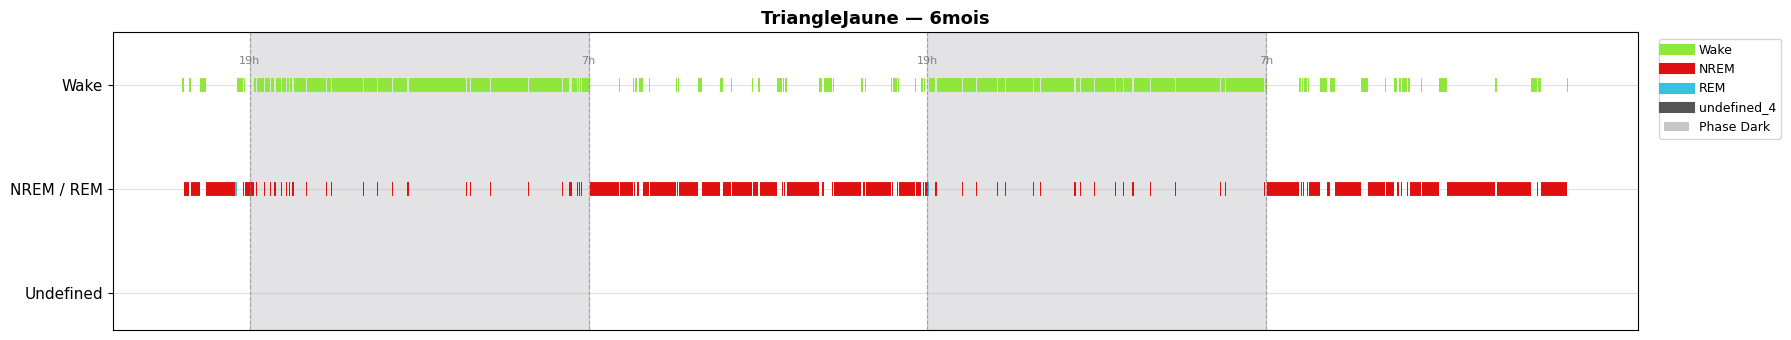

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleJaune\6mois\Hypnogramme_TriangleJaune_6mois.png

  Souris : TriangleJaune  |  Age : 7mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8521 epochs | duree totale : 49.26h
   Contenu recording_start.txt : [17/12/2025 16:47:38]
   Debut enregistrement : 2025-12-17 16:47:38  (format %d/%m/%Y %H:%M:%S)
   1125 episodes regroupe(s)


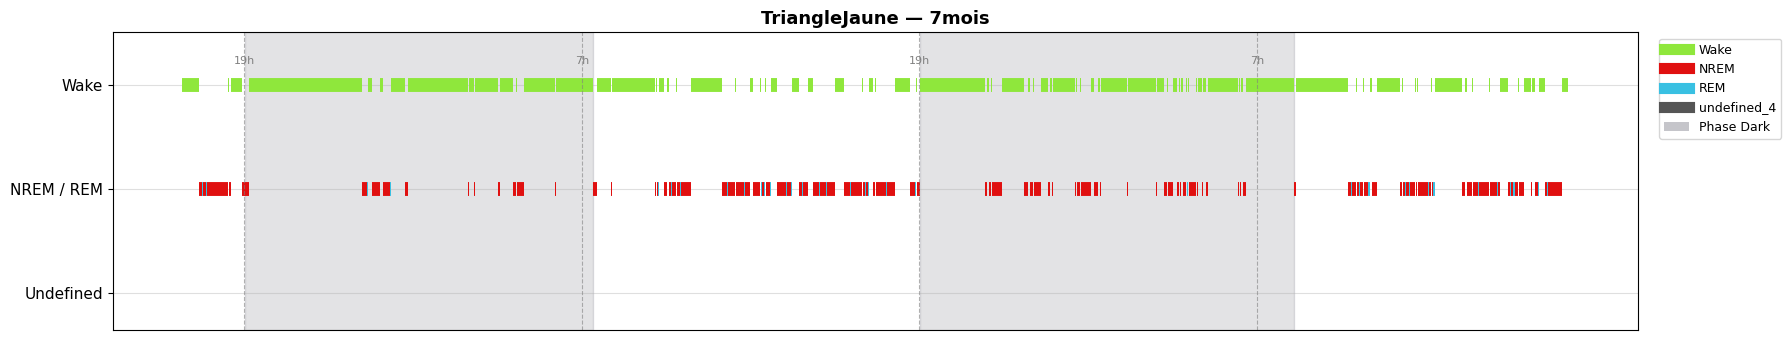

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleJaune\7mois\Hypnogramme_TriangleJaune_7mois.png

  Souris : TriangleMarron  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34314 epochs | duree totale : 47.66h
   Contenu recording_start.txt : [09/09/2025 17:25:54]
   Debut enregistrement : 2025-09-09 17:25:54  (format %d/%m/%Y %H:%M:%S)
   276 episodes regroupe(s)


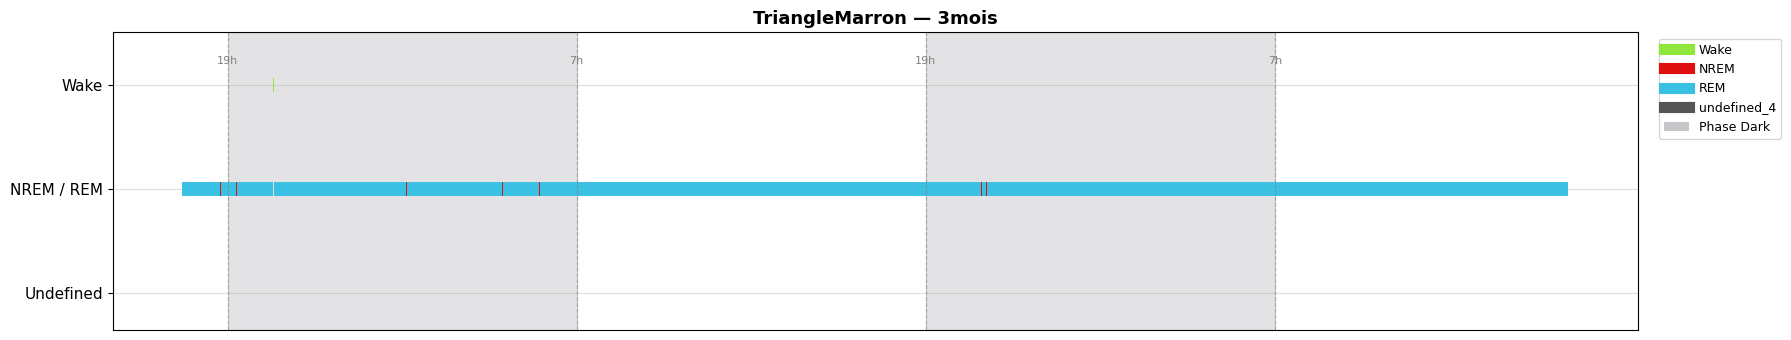

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleMarron\3mois\Hypnogramme_TriangleMarron_3mois.png

  Souris : TriangleMarron  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46406 epochs | duree totale : 64.45h
   Contenu recording_start.txt : [14/10/2025 16:26:19]
   Debut enregistrement : 2025-10-14 16:26:19  (format %d/%m/%Y %H:%M:%S)
   2513 episodes regroupe(s)


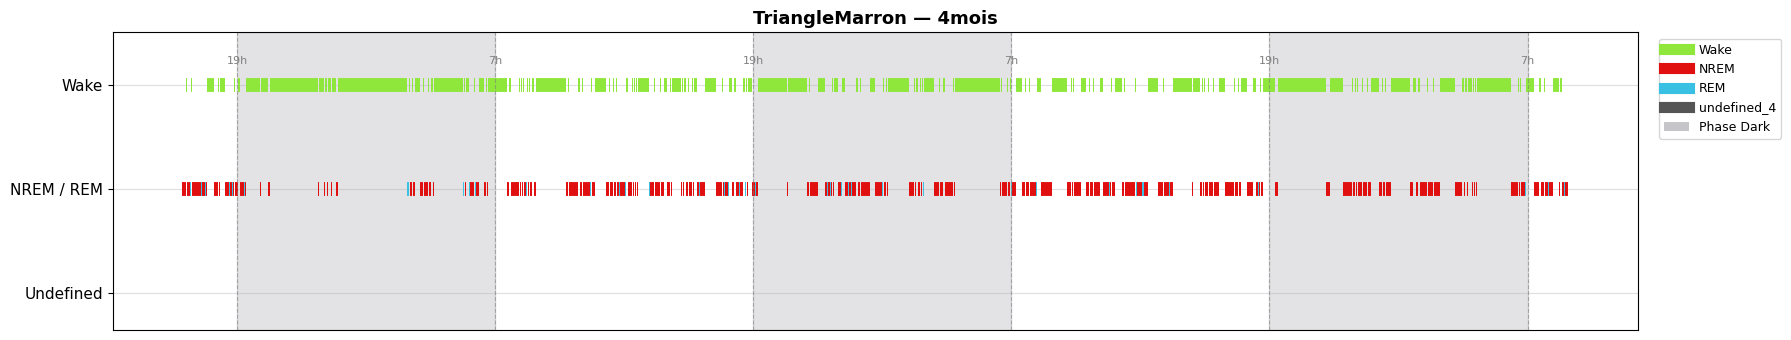

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleMarron\4mois\Hypnogramme_TriangleMarron_4mois.png

  Souris : TriangleMarron  |  Age : 5mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34895 epochs | duree totale : 48.47h
   Contenu recording_start.txt : [12/11/2025 17:35:16]
   Debut enregistrement : 2025-11-12 17:35:16  (format %d/%m/%Y %H:%M:%S)
   1389 episodes regroupe(s)


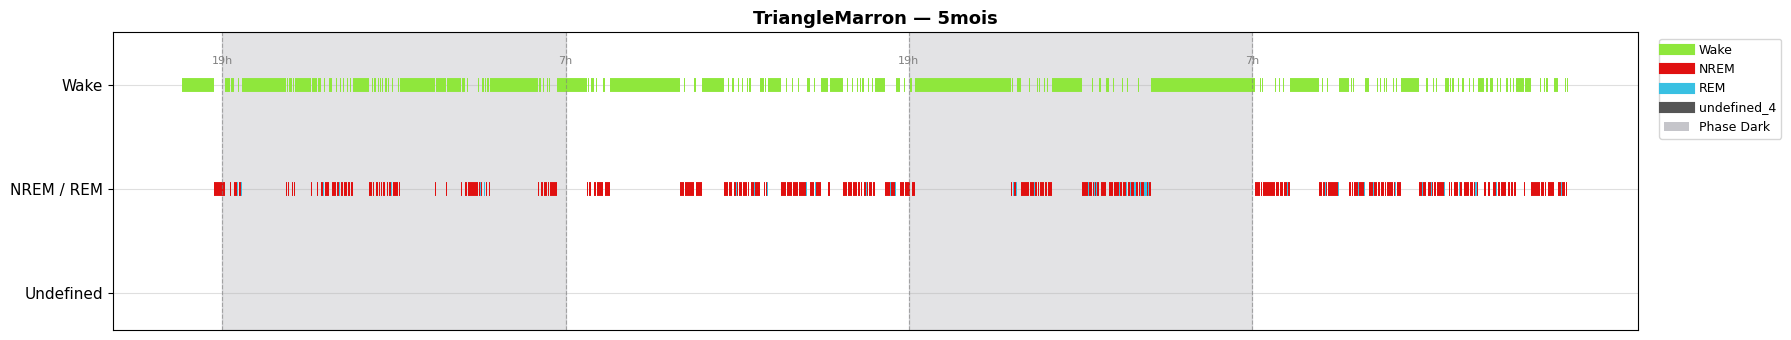

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleMarron\5mois\Hypnogramme_TriangleMarron_5mois.png

  Souris : TriangleMarron  |  Age : 6mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8201 epochs | duree totale : 48.75h
   Contenu recording_start.txt : [08/12/2025 17:02:15]
   Debut enregistrement : 2025-12-08 17:02:15  (format %d/%m/%Y %H:%M:%S)
   915 episodes regroupe(s)


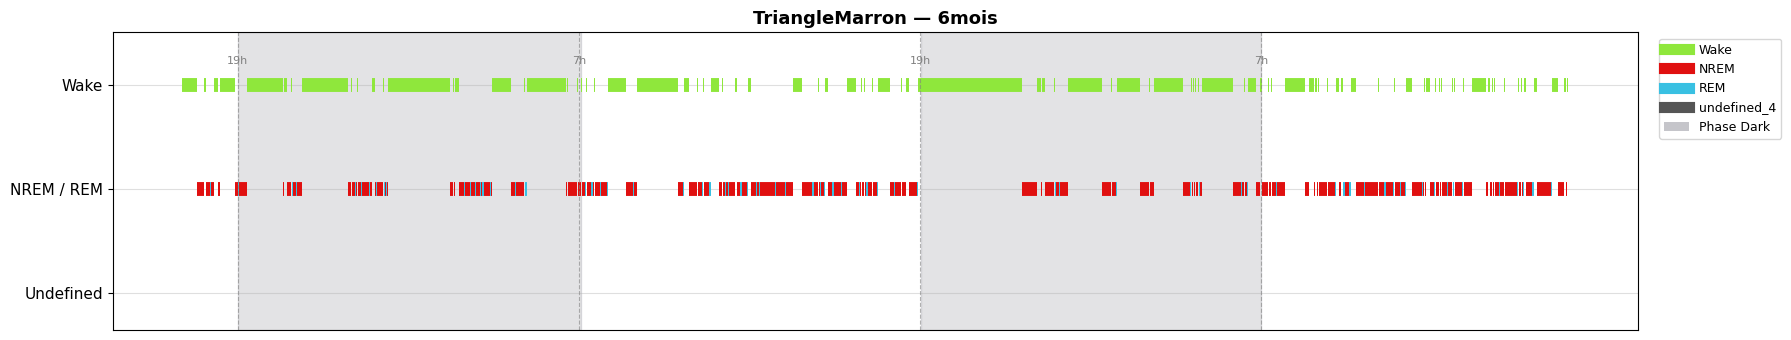

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleMarron\6mois\Hypnogramme_TriangleMarron_6mois.png

  Souris : TriangleMarron  |  Age : 7mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10458 epochs | duree totale : 47.96h
   Contenu recording_start.txt : [14/01/2026 17:23:19]
   Debut enregistrement : 2026-01-14 17:23:19  (format %d/%m/%Y %H:%M:%S)
   1349 episodes regroupe(s)


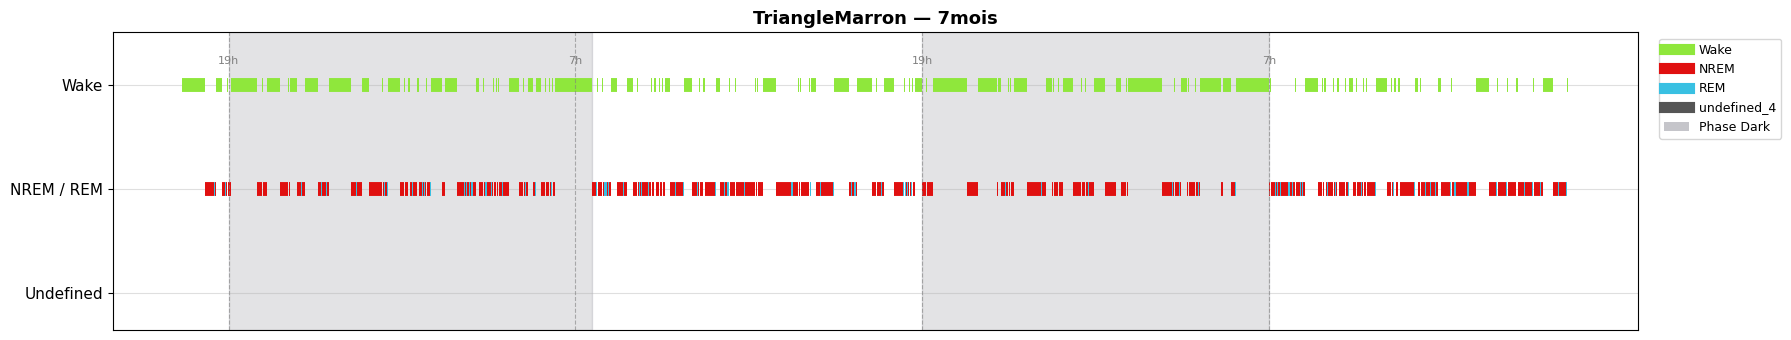

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleMarron\7mois\Hypnogramme_TriangleMarron_7mois.png

  Souris : TriangleNoir  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34314 epochs | duree totale : 47.66h
   Contenu recording_start.txt : [09/09/2025 17:25:54]
   Debut enregistrement : 2025-09-09 17:25:54  (format %d/%m/%Y %H:%M:%S)
   1128 episodes regroupe(s)


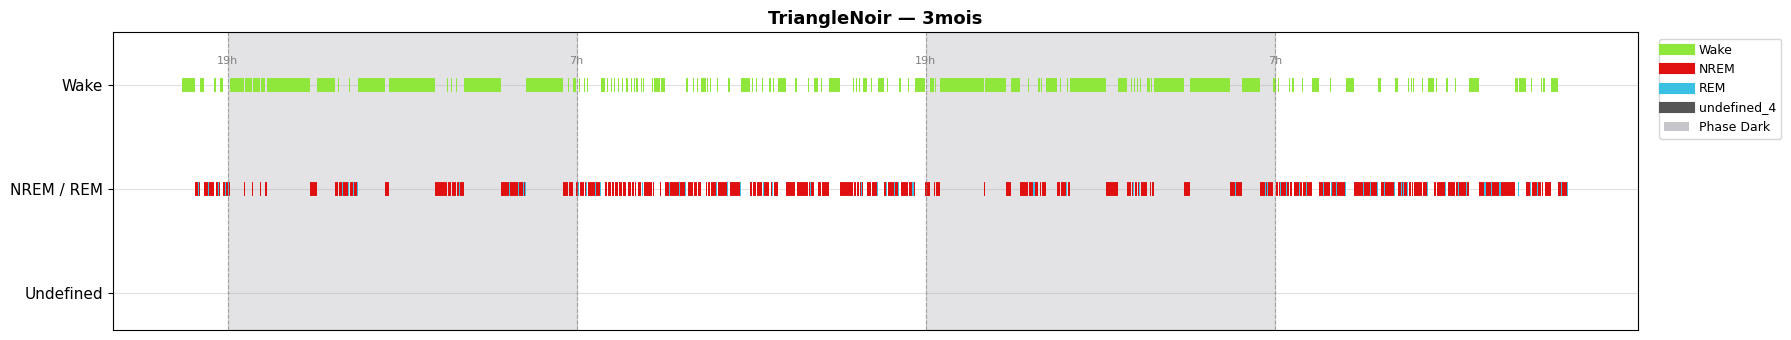

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleNoir\3mois\Hypnogramme_TriangleNoir_3mois.png

  Souris : TriangleNoir  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46406 epochs | duree totale : 64.45h
   Contenu recording_start.txt : [14/10/2025 16:26:19]
   Debut enregistrement : 2025-10-14 16:26:19  (format %d/%m/%Y %H:%M:%S)
   1219 episodes regroupe(s)


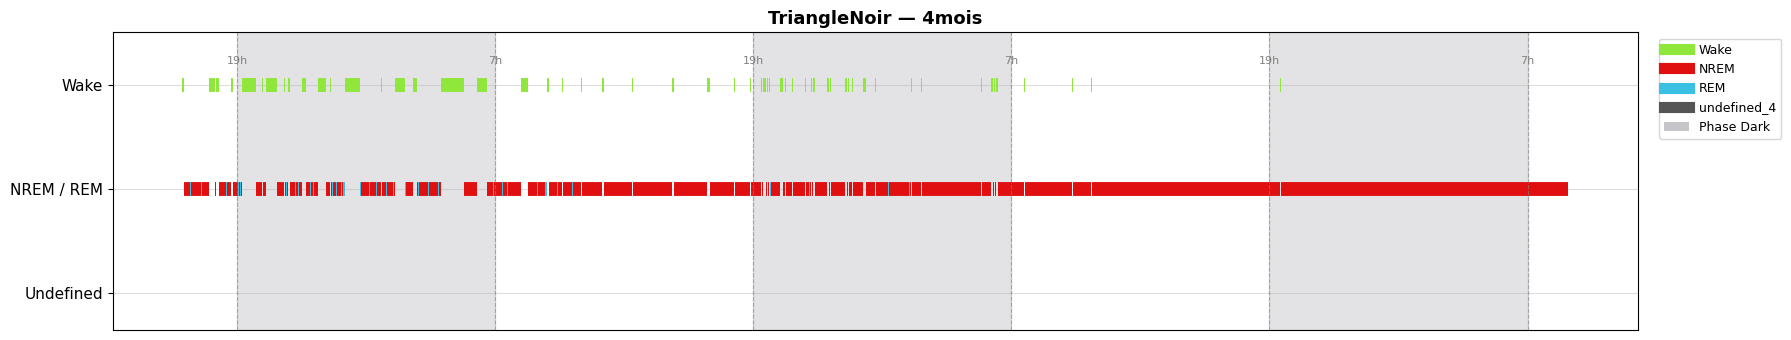

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleNoir\4mois\Hypnogramme_TriangleNoir_4mois.png

  Souris : TriangleOrange  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34767 epochs | duree totale : 48.29h
   Contenu recording_start.txt : [19/08/2025 16:25:28]
   Debut enregistrement : 2025-08-19 16:25:28  (format %d/%m/%Y %H:%M:%S)
   1692 episodes regroupe(s)


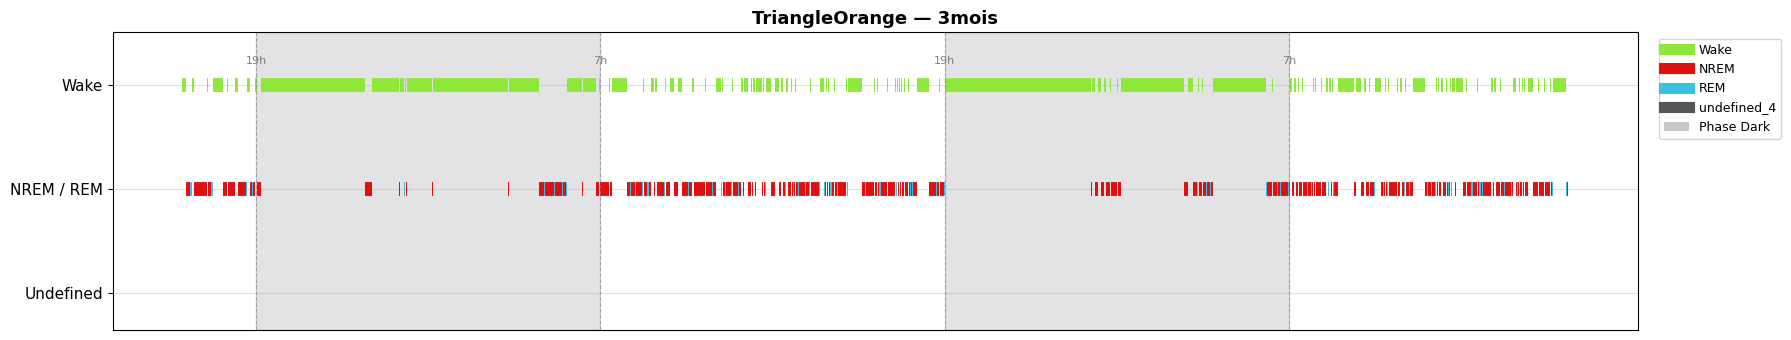

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleOrange\3mois\Hypnogramme_TriangleOrange_3mois.png

  Souris : TriangleRouge  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   17742 epochs | duree totale : 47.66h
   Contenu recording_start.txt : [09/09/2025 17:25:54]
   Debut enregistrement : 2025-09-09 17:25:54  (format %d/%m/%Y %H:%M:%S)
   1050 episodes regroupe(s)


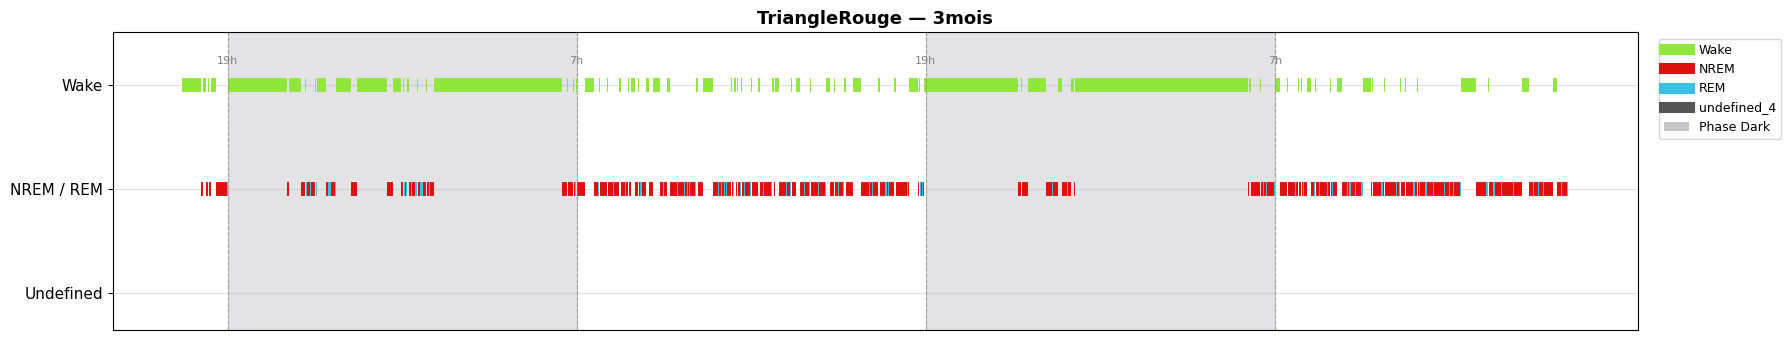

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleRouge\3mois\Hypnogramme_TriangleRouge_3mois.png

  Souris : TriangleRouge  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10325 epochs | duree totale : 64.45h
   Contenu recording_start.txt : [14/10/2025 16:26:19]
   Debut enregistrement : 2025-10-14 16:26:19  (format %d/%m/%Y %H:%M:%S)
   1164 episodes regroupe(s)


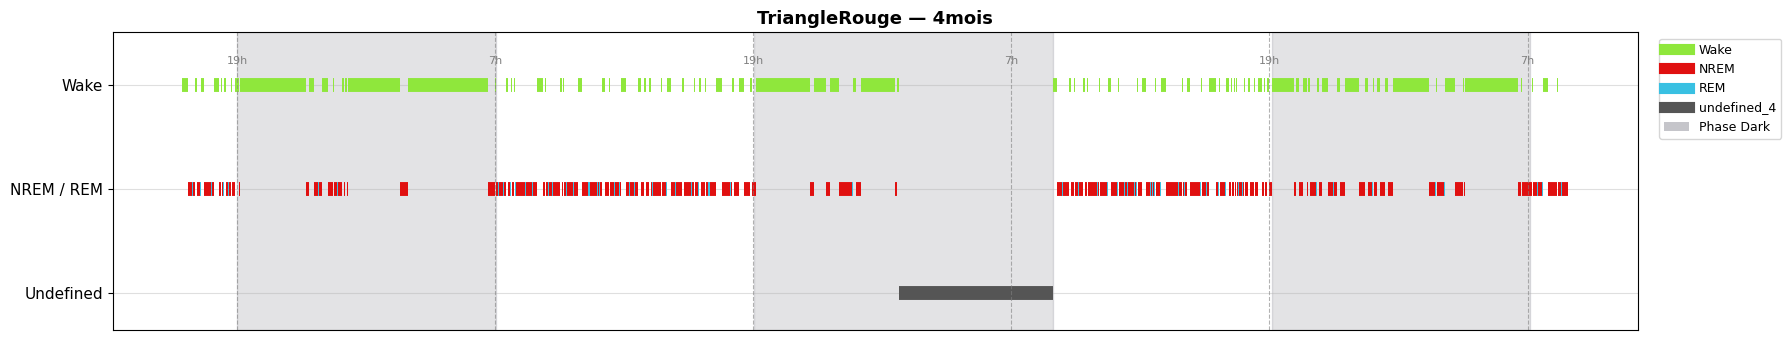

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleRouge\4mois\Hypnogramme_TriangleRouge_4mois.png

  Souris : TriangleRouge  |  Age : 5mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8704 epochs | duree totale : 48.47h
   Contenu recording_start.txt : [12/11/2025 17:35:16]
   Debut enregistrement : 2025-11-12 17:35:16  (format %d/%m/%Y %H:%M:%S)
   864 episodes regroupe(s)


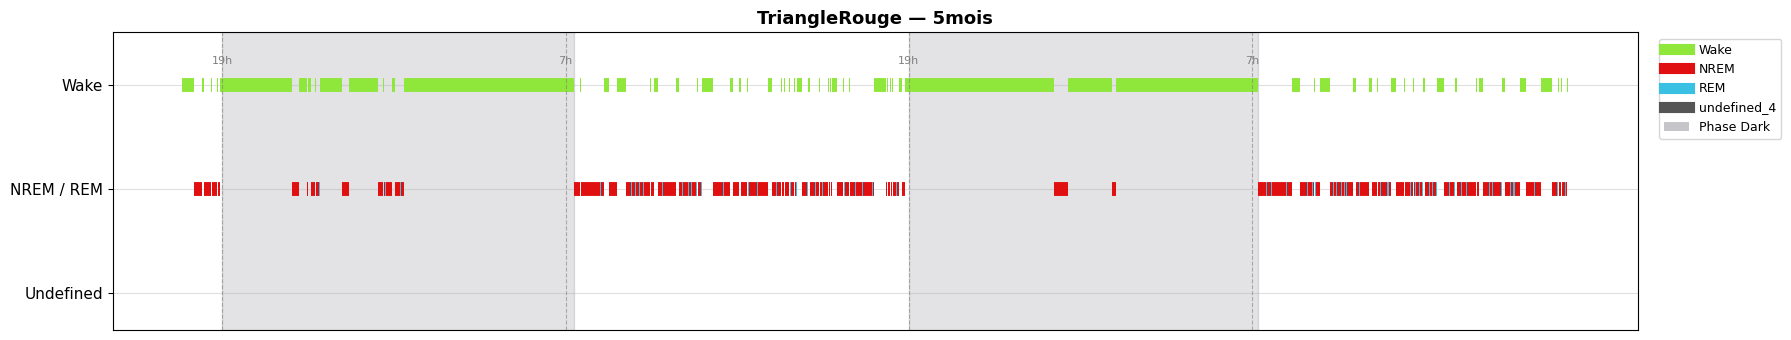

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleRouge\5mois\Hypnogramme_TriangleRouge_5mois.png

  Souris : TriangleRouge  |  Age : 6mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   35105 epochs | duree totale : 48.76h
   Contenu recording_start.txt : [08/12/2025 17:02:15]
   Debut enregistrement : 2025-12-08 17:02:15  (format %d/%m/%Y %H:%M:%S)
   901 episodes regroupe(s)


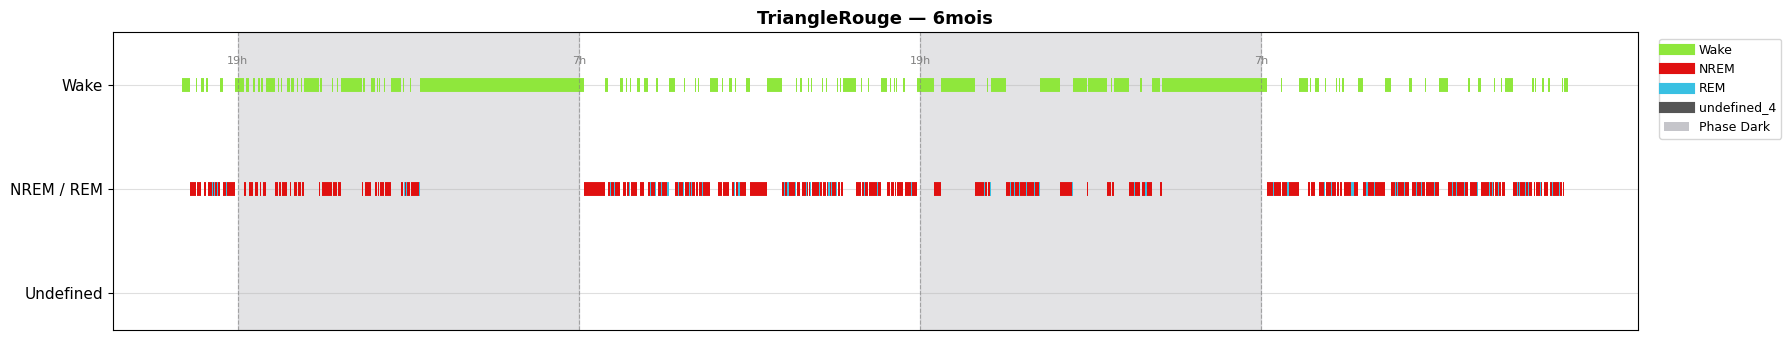

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleRouge\6mois\Hypnogramme_TriangleRouge_6mois.png

  Souris : TriangleRouge  |  Age : 7mois
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   32916 epochs | duree totale : 45.32h
   Contenu recording_start.txt : [14/01/2026 17:23:19]
   Debut enregistrement : 2026-01-14 17:23:19  (format %d/%m/%Y %H:%M:%S)
   1133 episodes regroupe(s)


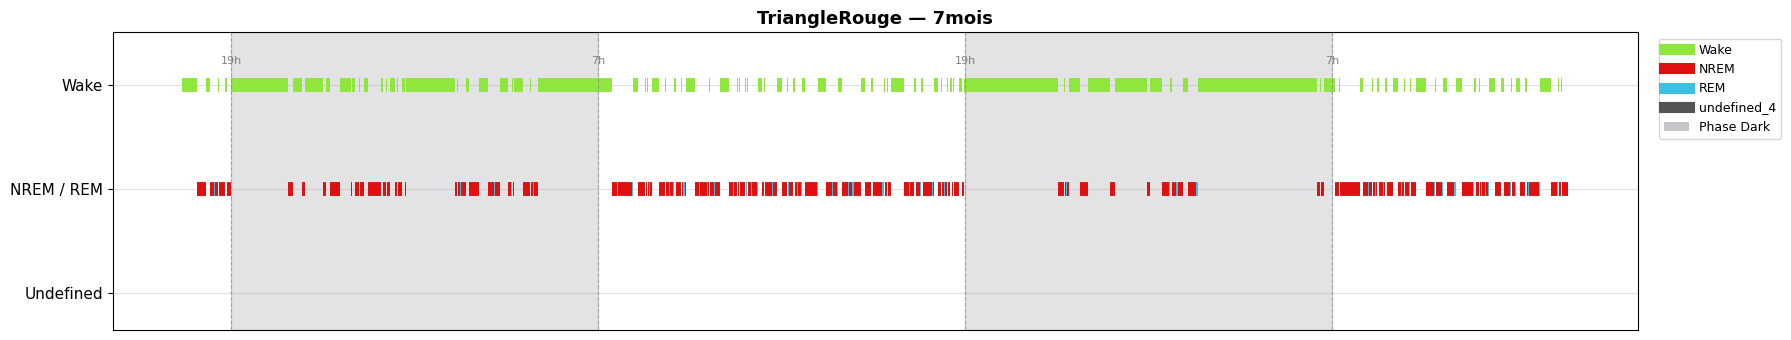

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleRouge\7mois\Hypnogramme_TriangleRouge_7mois.png

  Souris : TriangleVert  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34622 epochs | duree totale : 48.09h
   Contenu recording_start.txt : [11/09/2025 17:44:25]
   Debut enregistrement : 2025-09-11 17:44:25  (format %d/%m/%Y %H:%M:%S)
   1336 episodes regroupe(s)


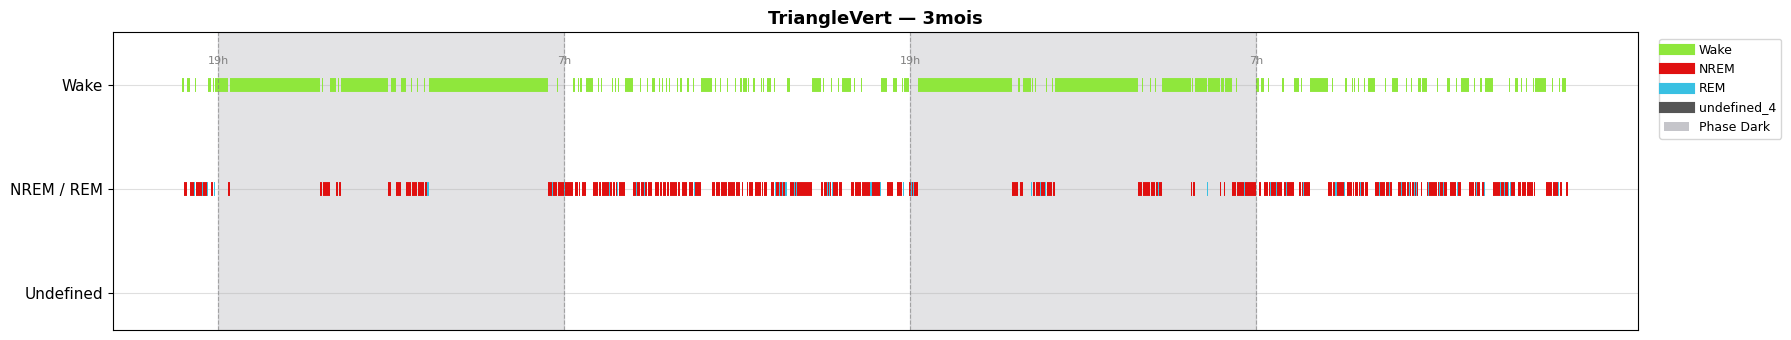

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleVert\3mois\Hypnogramme_TriangleVert_3mois.png

  Souris : TriangleVert  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46702 epochs | duree totale : 64.86h
   Contenu recording_start.txt : [24/09/2025 16:33:51]
   Debut enregistrement : 2025-09-24 16:33:51  (format %d/%m/%Y %H:%M:%S)
   2585 episodes regroupe(s)


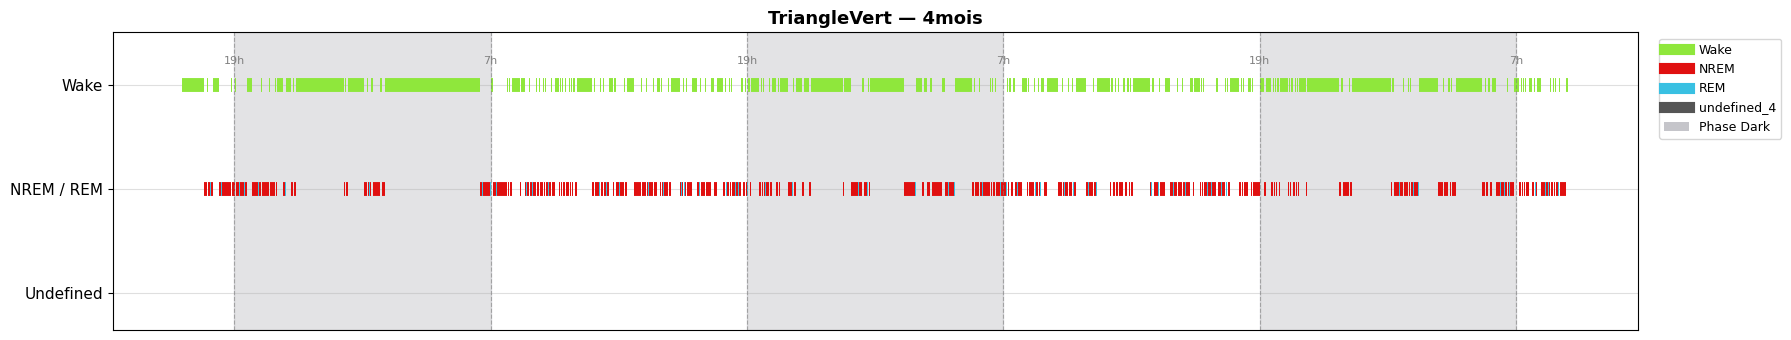

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleVert\4mois\Hypnogramme_TriangleVert_4mois.png

  Souris : TriangleViolet  |  Age : 3mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34767 epochs | duree totale : 48.29h
   Contenu recording_start.txt : [19/08/2025 16:25:28]
   Debut enregistrement : 2025-08-19 16:25:28  (format %d/%m/%Y %H:%M:%S)
   3540 episodes regroupe(s)


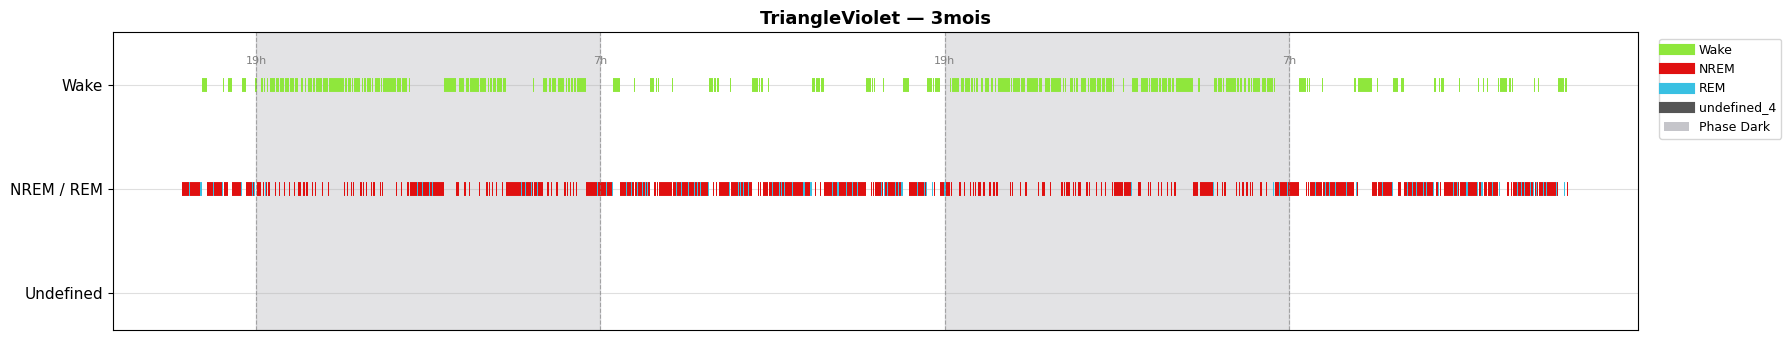

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleViolet\3mois\Hypnogramme_TriangleViolet_3mois.png

  Souris : TriangleViolet  |  Age : 4mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46702 epochs | duree totale : 64.86h
   Contenu recording_start.txt : [24/09/2025 16:33:51]
   Debut enregistrement : 2025-09-24 16:33:51  (format %d/%m/%Y %H:%M:%S)
   1165 episodes regroupe(s)


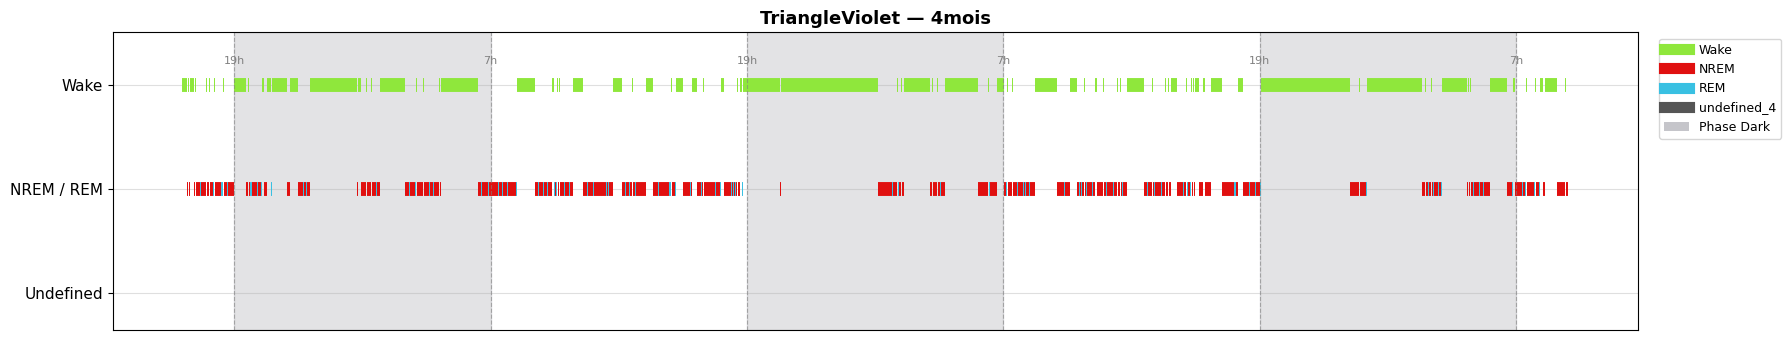

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleViolet\4mois\Hypnogramme_TriangleViolet_4mois.png

  Souris : TriangleViolet  |  Age : 5mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34952 epochs | duree totale : 48.54h
   Contenu recording_start.txt : [22/10/2025 16:20:15]
   Debut enregistrement : 2025-10-22 16:20:15  (format %d/%m/%Y %H:%M:%S)
   5871 episodes regroupe(s)


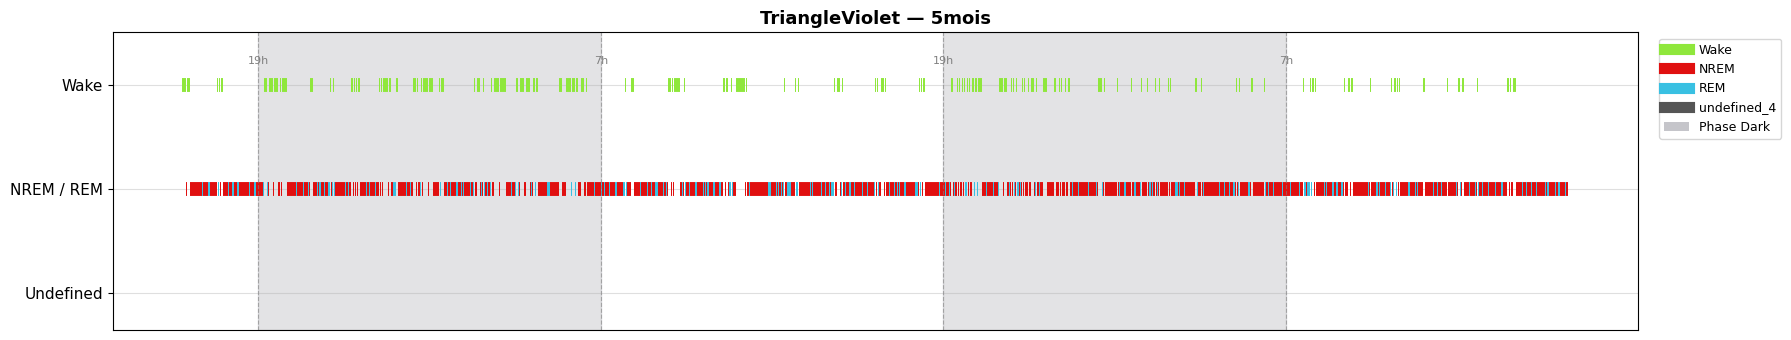

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleViolet\5mois\Hypnogramme_TriangleViolet_5mois.png

  Souris : TriangleViolet  |  Age : 6mois
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   35362 epochs | duree totale : 49.11h
   Contenu recording_start.txt : [24/11/2025 16:35:44]
   Debut enregistrement : 2025-11-24 16:35:44  (format %d/%m/%Y %H:%M:%S)
   1053 episodes regroupe(s)


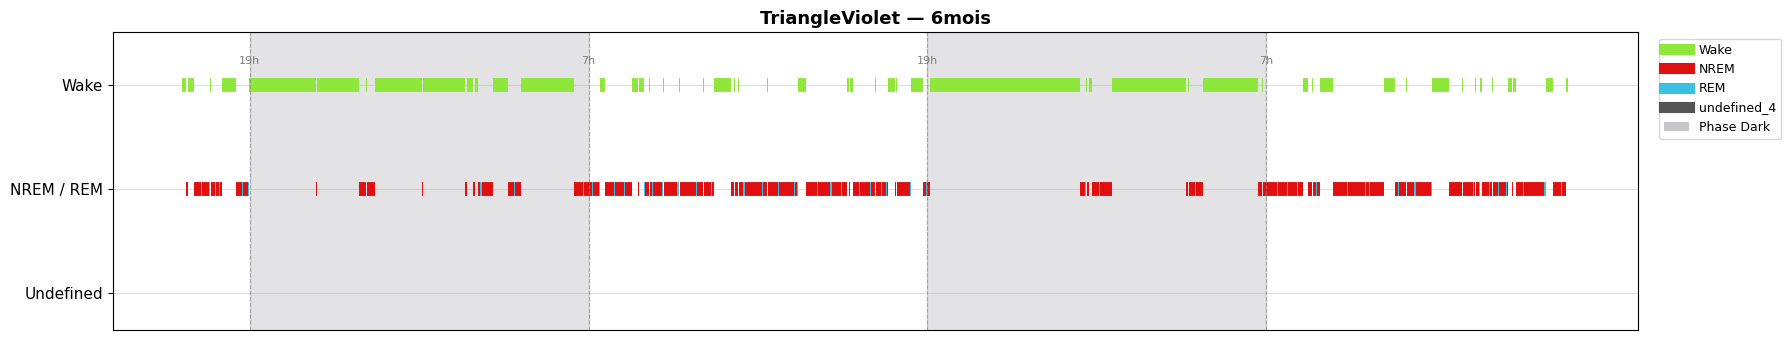

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleViolet\6mois\Hypnogramme_TriangleViolet_6mois.png


Analyse terminee : 120 lignes de resultats collectees


In [10]:
# =================================================================
# CELLULE 4 - BOUCLE PRINCIPALE : ANALYSE DE TOUS LES FICHIERS
# =================================================================

all_results = []

for entry in fichiers_trouves:
    mice     = entry['mice']
    age      = entry['age']
    csv_path = entry['path']
    dpath    = os.path.dirname(csv_path)

    print(f"\n{'='*65}")
    print(f"  Souris : {mice}  |  Age : {age}")
    print(f"{'='*65}")

    # -- Chargement CSV (detection automatique du separateur) -------
    # pd.read_csv avec le mauvais sep ne plante pas mais cree 1 seule colonne
    for sep in [',', ';', '\t']:
        df_raw = pd.read_csv(csv_path, sep=sep)
        df_raw.columns = df_raw.columns.str.strip()
        if len(df_raw.columns) > 1:
            print(f"   Separateur detecte : [{sep}]")
            break
    else:
        print(f"   ERREUR : separateur non detecte dans {csv_path} — souris ignoree")
        continue

    if 'time' in df_raw.columns and 'start_time' not in df_raw.columns:
        df_raw = df_raw.rename(columns={'time': 'start_time'})
        df_raw['end_time'] = df_raw['start_time'] + df_raw['duration']

    print(f"   Colonnes : {df_raw.columns.tolist()}")
    print(f"   {len(df_raw)} epochs | duree totale : {df_raw['duration'].sum()/3600:.2f}h")

    # -- Lecture recording_start.txt ---------------------------------
    # utf-8-sig gere automatiquement le BOM Windows (\ufeff)
    txt_path = os.path.join(dpath, 'recording_start.txt')
    if not os.path.exists(txt_path):
        print(f"   ERREUR : recording_start.txt introuvable dans {dpath} — souris ignoree")
        continue

    try:
        with open(txt_path, 'r', encoding='utf-8-sig') as f:
            raw_content = f.read().strip()
        print(f"   Contenu recording_start.txt : [{raw_content}]")  # debug

        # Essai de plusieurs formats courants
        recording_start = None
        for fmt in ['%d/%m/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S',
                    '%d-%m-%Y %H:%M:%S', '%m/%d/%Y %H:%M:%S']:
            try:
                recording_start = datetime.strptime(raw_content, fmt)
                print(f"   Debut enregistrement : {recording_start}  (format {fmt})")
                break
            except ValueError:
                continue

        if recording_start is None:
            print(f"   ERREUR : format de date non reconnu : [{raw_content}] — souris ignoree")
            continue

    except Exception as e:
        print(f"   ERREUR lecture recording_start.txt : {e} — souris ignoree")
        continue

    # -- Horodatages & phases ----------------------------------------
    df_raw['abs_datetime'] = [
        recording_start + timedelta(seconds=float(t))
        for t in df_raw['start_time']
    ]
    df_raw['phase'] = df_raw['abs_datetime'].apply(assign_phase)

    # -- Regroupement episodes ---------------------------------------
    df_episodes = regrouper_episodes(df_raw)
    print(f"   {len(df_episodes)} episodes regroupe(s)")

    # -- Hypnogramme -------------------------------------------------
    tracer_hypnogramme(df_raw, df_episodes, mice, age, dpath)

    # -- Analyse Light & Dark ----------------------------------------
    for phase in ['Light', 'Dark']:
        res = analyser_phase(phase, df_raw, df_episodes, mice, age)
        if res:
            all_results.append(res)

print(f"\n\nAnalyse terminee : {len(all_results)} lignes de resultats collectees")


In [11]:
# =================================================================
# CELLULE 5 - TABLEAU RECAPITULATIF UNIQUE
# =================================================================

df_summary = pd.DataFrame(all_results)

# Colonnes d'identification en premier
id_cols    = ['mice', 'age', 'phase', 'duree_h']
other_cols = [c for c in df_summary.columns if c not in id_cols]
df_summary = df_summary[id_cols + other_cols]

# Tri : souris -> age -> phase (Light avant Dark)
phase_order = {'Light': 0, 'Dark': 1}
df_summary['_phase_order'] = df_summary['phase'].map(phase_order)
df_summary = (df_summary
              .sort_values(['mice', 'age', '_phase_order'])
              .drop(columns='_phase_order')
              .reset_index(drop=True))

print(f"Tableau recapitulatif : {len(df_summary)} lignes x {len(df_summary.columns)} colonnes")
display(df_summary)

# -- Sauvegarde CSV --------------------------------------------------
output_csv = os.path.join(BASE_PATH, 'Summary_Sleep_AllMice.csv')
df_summary.to_csv(output_csv, index=False, sep=';', encoding='utf-8-sig')
print(f"\nCSV sauvegarde : {output_csv}")

# -- Sauvegarde Excel (3 feuilles : Summary / Light / Dark) ----------
output_xlsx = os.path.join(BASE_PATH, 'Summary_Sleep_AllMice.xlsx')
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    df_summary.to_excel(writer, index=False, sheet_name='Summary')
    for phase in ['Light', 'Dark']:
        df_summary[df_summary['phase'] == phase].to_excel(
            writer, index=False, sheet_name=phase)

print(f"Excel sauvegarde  : {output_xlsx}")
print(f"\nTermine ! {len(fichiers_trouves)} souris analysees.")


Tableau recapitulatif : 120 lignes x 40 colonnes


,mice,age,phase,duree_h,Wake_n_episodes,Wake_mean_dur_min,Wake_median_dur_min,Wake_pct,Wake_min_per_12h,Wake_min_per_h,...,trans_NREM_to_REM,trans_NREM_to_REM_per_h,trans_REM_to_NREM,trans_REM_to_NREM_per_h,micro_n,micro_per_h,micro_mean_s,micro_nrem_n,micro_nrem_per_h,micro_nrem_mean_s
0,CarreBlanc,3mois,Light,23.770,473,1.04,0.08,36.2,260.6,21.72,...,77,3.239,6,0.252,310,13.041,6.0,270,11.359,5.4
1,CarreBlanc,3mois,Dark,24.335,213,4.99,0.08,71.2,512.9,42.74,...,49,2.014,2,0.082,118,4.849,5.1,103,4.233,4.7
2,CarreBlanc,4mois,Light,22.692,320,1.27,0.08,29.7,214.1,17.84,...,99,4.363,0,0.000,224,9.871,6.2,154,6.787,5.7
3,CarreBlanc,4mois,Dark,25.591,201,5.29,0.08,69.2,498.3,41.52,...,60,2.345,1,0.039,142,5.549,5.8,97,3.790,5.0
4,CarreJaune,3mois,Light,24.461,1665,0.39,0.17,44.8,322.4,26.86,...,0,0.000,0,0.000,1242,50.774,7.6,1242,50.774,7.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,TriangleViolet,4mois,Dark,36.000,164,8.72,0.33,71.7,516.4,43.03,...,56,1.556,5,0.139,71,1.972,8.2,46,1.278,7.4
116,TriangleViolet,5mois,Light,24.544,516,0.33,0.17,11.6,83.7,6.98,...,871,35.487,823,33.531,357,14.545,8.3,200,8.148,8.1
117,TriangleViolet,5mois,Dark,24.000,736,0.48,0.25,24.4,175.5,14.62,...,863,35.958,809,33.708,409,17.042,7.8,253,10.542,7.8
118,TriangleViolet,6mois,Light,25.114,174,2.94,0.25,24.5,176.4,14.70,...,277,11.030,255,10.154,94,3.743,7.5,86,3.424,7.3



CSV sauvegarde : Z:\forgetting\Carla\SleepRecordings\Summary_Sleep_AllMice.csv
Excel sauvegarde  : Z:\forgetting\Carla\SleepRecordings\Summary_Sleep_AllMice.xlsx

Termine ! 60 souris analysees.
